### LIBs

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import plotly.express as px
from streamlit import header
from sklearn.model_selection import StratifiedKFold,ParameterGrid
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression as LR
from sklearn.model_selection import train_test_split
import category_encoders as ce
import numpy as np
from unicodedata import category
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,roc_auc_score,ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix,roc_curve, auc,precision_recall_curve, average_precision_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score as acc
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.pipeline import Pipeline
import tensorflow as tf
from tensorflow.keras import Sequential
warnings.filterwarnings('ignore')


### FUN

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    fbeta_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)


def safe_index(X, idx):
    if hasattr(X, "iloc"):
        return X.iloc[idx]
    return X[idx]


def make_pipeline(model_builder, params, scaler_class=None):
    steps = []

    if scaler_class is not None:
        steps.append(("scaler", scaler_class()))

    steps.append(("model", model_builder(**params)))

    return Pipeline(steps)


def get_pos_prob(model, X):
    prob = model.predict_proba(X)
    return prob[:, 1]


def get_cv_prob(X,y,model_builder,params,scaler_class=None,cv_splits=5,random_state=1):
    y_series = pd.Series(y).reset_index(drop=True)

    if hasattr(X, "reset_index"):
        X_work = X.reset_index(drop=True)
    else:
        X_work = X

    model_prob = np.zeros(len(y_series))

    cv = StratifiedKFold(n_splits=cv_splits,shuffle=True,random_state=random_state)

    for train_idx, valid_idx in cv.split(X_work, y_series):
        X_tr = safe_index(X_work, train_idx)
        X_val = safe_index(X_work, valid_idx)
        y_tr = y_series.iloc[train_idx]

        model = make_pipeline(model_builder=model_builder,params=params,scaler_class=scaler_class)

        model.fit(X_tr, y_tr)

        model_prob[valid_idx] = get_pos_prob(model, X_val)

    return model_prob


def calculate_threshold_metrics(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.round(np.arange(0.01, 1.00, 0.01), 2)

    rows = []
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        
        recall = recall_score(y_true, y_pred, zero_division=0)
        precision = precision_score(y_true, y_pred, zero_division=0)
        accuracy = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        rows.append({
            "threshold": threshold,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "accuracy": accuracy,
            "recall": recall,
            "precision": precision,
            "specificity": specificity,
            "f1": f1,
            "f2": f2
        })

    return pd.DataFrame(rows)


def choose_best_threshold(threshold_results,target_recall=0.985,selection_metric="accuracy"):
    valid = threshold_results[
        threshold_results["recall"] >= target_recall
    ].copy()

    if len(valid) > 0:
        best_row = valid.sort_values(
            by=[selection_metric, "precision", "accuracy", "FP", "FN", "threshold"],
            ascending=[False, False, False, True, True, False]
        ).iloc[0]

        hit_target = True

    else:
        best_row = threshold_results.sort_values(
            by=["recall", selection_metric, "precision", "accuracy", "FP"],
            ascending=[False, False, False, False, True]
        ).iloc[0]

        hit_target = False

    return best_row, hit_target


def tune_model_with_threshold(
    X_train,
    y_train,
    model_builder,
    param_grid,
    scaler_class=None,
    target_recall=0.985,
    selection_metric="accuracy",
    thresholds=None,
    cv_splits=5,
    random_state=1,
    verbose=True
):
    all_rows = []
    threshold_tables = {}

    for i, params in enumerate(ParameterGrid(param_grid), start=1):
        try:
            model_prob = get_cv_prob(
                X=X_train,
                y=y_train,
                model_builder=model_builder,
                params=params,
                scaler_class=scaler_class,
                cv_splits=cv_splits,
                random_state=random_state
            )

            threshold_results = calculate_threshold_metrics(
                y_true=np.array(y_train),
                y_prob=model_prob,
                thresholds=thresholds
            )

            best_threshold_row, hit_target = choose_best_threshold(
                threshold_results=threshold_results,
                target_recall=target_recall,
                selection_metric=selection_metric
            )

            param_id = f"params_{i}"
            threshold_tables[param_id] = threshold_results

            row = {
                "param_id": param_id,
                **params,
                "best_threshold": best_threshold_row["threshold"],
                "hit_target_recall": hit_target,
                "CV_TP": int(best_threshold_row["TP"]),
                "CV_TN": int(best_threshold_row["TN"]),
                "CV_FP": int(best_threshold_row["FP"]),
                "CV_FN": int(best_threshold_row["FN"]),
                "CV_accuracy": best_threshold_row["accuracy"],
                "CV_recall": best_threshold_row["recall"],
                "CV_precision": best_threshold_row["precision"],
                "CV_specificity": best_threshold_row["specificity"],
                "CV_f1": best_threshold_row["f1"],
                "CV_f2": best_threshold_row["f2"],
                "CV_roc_auc": roc_auc_score(y_train, model_prob),
                "CV_pr_auc": average_precision_score(y_train, model_prob)
            }

            all_rows.append(row)

            if verbose:
                print(
                    f"Done {i}/{len(list(ParameterGrid(param_grid)))} | "
                    f"Recall={row['CV_recall']:.4f} | "
                    f"Accuracy={row['CV_accuracy']:.4f} | "
                    f"Threshold={row['best_threshold']}"
                )

        except Exception as e:
            print(f"Skipped params {params} because of error: {e}")

    results_df = pd.DataFrame(all_rows)

    if results_df.empty:
        raise ValueError("No valid model configurations were successfully fitted.")

    valid_models = results_df[results_df["hit_target_recall"] == True].copy()

    metric_col = f"CV_{selection_metric}"

    if len(valid_models) > 0:
        best_model_row = valid_models.sort_values(
            by=[metric_col, "CV_precision", "CV_accuracy", "CV_FP", "CV_FN", "best_threshold"],
            ascending=[False, False, False, True, True, False]
        ).iloc[0]
    else:
        best_model_row = results_df.sort_values(
            by=["CV_recall", metric_col, "CV_precision", "CV_accuracy", "CV_FP"],
            ascending=[False, False, False, False, True]
        ).iloc[0]

    best_params = {
        key: best_model_row[key]
        for key in param_grid.keys()
    }

    best_threshold = float(best_model_row["best_threshold"])

    final_model = make_pipeline(
        model_builder=model_builder,
        params=best_params,
        scaler_class=scaler_class
    )

    final_model.fit(X_train, y_train)

    feature_names = list(X_train.columns) if hasattr(X_train, "columns") else None

    tuned_object = {
        "model": final_model,
        "best_params": best_params,
        "threshold": best_threshold,
        "cv_results": results_df.sort_values(
            by=["hit_target_recall", metric_col, "CV_recall", "CV_accuracy"],
            ascending=[False, False, False, False]
        ).reset_index(drop=True),
        "best_cv_row": best_model_row,
        "best_threshold_results": threshold_tables[best_model_row["param_id"]],
        "target_recall": target_recall,
        "selection_metric": selection_metric,
        "feature_names": feature_names
    }

    print("\nBest Params:")
    print(best_params)

    print("\nBest Threshold:")
    print(best_threshold)

    print("\nBest CV Row:")
    display(pd.DataFrame([best_model_row]))

    return tuned_object

In [14]:
def evaluate_tuned_model(tuned_object, X, y, dataset_name="Test"):
    model = tuned_object["model"]
    threshold = tuned_object["threshold"]

    y_prob = get_pos_prob(model, X)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    metrics = {
        "dataset": dataset_name,
        "threshold": threshold,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "accuracy": accuracy_score(y, y_pred),
        "recall": recall_score(y, y_pred, zero_division=0),
        "precision": precision_score(y, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "f1": f1_score(y, y_pred, zero_division=0),
        "f2": fbeta_score(y, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y, y_prob),
        "pr_auc": average_precision_score(y, y_prob)
    }

    print(f"{dataset_name} Metrics")
    print("-" * 40)
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")

    print("\nClassification Report:")
    print(classification_report(y, y_pred, target_names=["Non GDM", "GDM"]))

    prediction_df = X.copy()
    prediction_df["Actual_GDM"] = np.array(y)
    prediction_df["GDM_Probability"] = y_prob
    prediction_df["Predicted_GDM"] = y_pred

    return metrics, prediction_df

In [15]:
def plot_threshold_tuning(tuned_object):
    threshold_results = tuned_object["best_threshold_results"]
    best_threshold = tuned_object["threshold"]
    target_recall = tuned_object["target_recall"]

    plt.figure(figsize=(9, 5))

    plt.plot(threshold_results["threshold"], threshold_results["recall"], label="Recall")
    plt.plot(threshold_results["threshold"], threshold_results["precision"], label="Precision")
    plt.plot(threshold_results["threshold"], threshold_results["accuracy"], label="Accuracy")
    plt.plot(threshold_results["threshold"], threshold_results["f2"], label="F2")

    plt.axvline(best_threshold, linestyle="--", label=f"Best Threshold = {best_threshold}")
    plt.axhline(target_recall, linestyle="--", label=f"Target Recall = {target_recall}")

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Threshold Tuning")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_tuned(tuned_object, X, y):
    model = tuned_object["model"]
    threshold = tuned_object["threshold"]

    y_prob = get_pos_prob(model, X)
    y_pred = (y_prob >= threshold).astype(int)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y, y_pred),
        display_labels=["Non GDM", "GDM"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix at Threshold = {threshold}")
    plt.tight_layout()
    plt.show()


def plot_roc_and_pr_curves(tuned_object, X, y):
    model = tuned_object["model"]
    y_prob = get_pos_prob(model, X)

    RocCurveDisplay.from_predictions(y, y_prob)
    plt.title("ROC Curve")
    plt.tight_layout()
    plt.show()

    PrecisionRecallDisplay.from_predictions(y, y_prob)
    plt.title("Precision-Recall Curve")
    plt.tight_layout()
    plt.show()


def plot_probability_distribution(tuned_object, X, y):
    model = tuned_object["model"]
    threshold = tuned_object["threshold"]

    y_prob = get_pos_prob(model, X)
    y_array = np.array(y)

    plt.figure(figsize=(9, 5))

    plt.hist(
        y_prob[y_array == 0],
        bins=30,
        alpha=0.6,
        label="Non GDM"
    )

    plt.hist(
        y_prob[y_array == 1],
        bins=30,
        alpha=0.6,
        label="GDM"
    )

    plt.axvline(threshold, linestyle="--", label=f"Threshold = {threshold}")

    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title("Probability Distribution by Actual Class")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_logistic_coefficients(tuned_object, top_n=None):
    model = tuned_object["model"]
    feature_names = tuned_object["feature_names"]

    if feature_names is None:
        print("Feature names are not available.")
        return

    final_estimator = model.named_steps["model"]

    if not hasattr(final_estimator, "coef_"):
        print("This plot is only available for linear models like Logistic Regression.")
        return

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": final_estimator.coef_[0]
    })

    coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

    if top_n is not None:
        coef_df = coef_df.head(top_n)

    coef_df = coef_df.sort_values("Coefficient")

    plt.figure(figsize=(9, 6))
    plt.barh(coef_df["Feature"], coef_df["Coefficient"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Coefficient")
    plt.title("Logistic Regression Coefficients")
    plt.tight_layout()
    plt.show()

    return coef_df


def plot_all_model_diagnostics(tuned_object, X, y):
    plot_threshold_tuning(tuned_object)
    plot_confusion_matrix_tuned(tuned_object, X, y)
    plot_roc_and_pr_curves(tuned_object, X, y)
    plot_probability_distribution(tuned_object, X, y)

### DATA

In [16]:
df = pd.read_csv('Gestational_Diabetic_Dat_Set.csv')


In [17]:
df.head()

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)
0,1,22,2,1,NaN,55.0,0,0,0,0,102.0,69,NaN,12.0,0,0,0
1,2,26,2,1,NaN,53.0,0,0,0,0,101.0,63,NaN,12.4,0,0,0
2,3,29,1,0,NaN,50.0,0,0,0,0,118.0,79,NaN,14.3,0,0,0
3,4,28,2,1,NaN,51.0,0,0,0,0,99.0,70,NaN,15.0,0,0,0
4,5,21,2,1,NaN,52.0,0,0,0,0,116.0,65,NaN,15.0,0,0,0


### EDA

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Case Number                      3525 non-null   int64  
 1   Age                              3525 non-null   int64  
 2   No of Pregnancy                  3525 non-null   int64  
 3   Gestation in previous Pregnancy  3525 non-null   int64  
 4   BMI                              2444 non-null   float64
 5   HDL                              2524 non-null   float64
 6   Family History                   3525 non-null   int64  
 7   unexplained prenetal loss        3525 non-null   int64  
 8   Large Child or Birth Default     3525 non-null   int64  
 9   PCOS                             3525 non-null   int64  
 10  Sys BP                           1820 non-null   float64
 11  Dia BP                           3525 non-null   int64  
 12  OGTT                

In [19]:
df.describe()

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)
count,3525.000000,3525.000000,3525.000000,3525.000000,2444.000000,2524.000000,3525.000000,3525.000000,3525.00000,3525.000000,1820.000000,3525.000000,3012.000000,3525.000000,3525.000000,3525.000000,3525.000000
mean,1763.000000,32.581277,2.076312,0.960851,27.854092,46.471870,0.498156,0.364823,0.35773,0.264681,135.762088,81.538156,170.707503,13.959801,0.449645,0.293050,0.389220
std,1017.724177,6.169107,0.838637,0.722313,5.714737,10.800813,0.500068,0.481449,0.47940,0.441226,22.742844,11.379758,48.160549,1.863969,0.497529,0.455226,0.487643
min,1.000000,20.000000,1.000000,0.000000,13.300000,15.000000,0.000000,0.000000,0.00000,0.000000,90.000000,60.000000,80.000000,8.800000,0.000000,0.000000,0.000000
25%,882.000000,28.000000,1.000000,0.000000,24.400000,42.000000,0.000000,0.000000,0.00000,0.000000,122.000000,74.000000,142.000000,12.700000,0.000000,0.000000,0.000000
50%,1763.000000,32.000000,2.000000,1.000000,27.500000,49.000000,0.000000,0.000000,0.00000,0.000000,132.000000,81.000000,156.000000,14.000000,0.000000,0.000000,0.000000
75%,2644.000000,37.000000,3.000000,1.000000,31.000000,55.000000,1.000000,1.000000,1.00000,1.000000,153.000000,86.000000,195.000000,15.000000,1.000000,1.000000,1.000000
max,3525.000000,45.000000,4.000000,2.000000,45.000000,70.000000,1.000000,1.000000,1.00000,1.000000,185.000000,124.000000,403.000000,18.000000,1.000000,1.000000,1.000000


In [20]:
df.isna().sum()

Case Number                           0
Age                                   0
No of Pregnancy                       0
Gestation in previous Pregnancy       0
BMI                                1081
HDL                                1001
Family History                        0
unexplained prenetal loss             0
Large Child or Birth Default          0
PCOS                                  0
Sys BP                             1705
Dia BP                                0
OGTT                                513
Hemoglobin                            0
Sedentary Lifestyle                   0
Prediabetes                           0
Class Label(GDM /Non GDM)             0
dtype: int64

In [21]:
df = df.rename(columns={
    "No of Pregnancy": "No_of_Pregnancy",
    "Gestation in previous Pregnancy": "Gestation_in_previous_Pregnancy",
    "Family History": "Family_History",
    "unexplained prenetal loss": "unexplained_prenetal_loss",
    "Large Child or Birth Default": "Large_Child_or_Birth_Default",
    "Class Label(GDM /Non GDM)": "GDM", 
    "Dia BP": "dia", 
    "Sys BP": "Sys", 
    "Sedentary Lifestyle": "Sedentary_Lifestyle", 
}, errors="ignore") 

In [22]:
df.isna().sum()

Case Number                           0
Age                                   0
No_of_Pregnancy                       0
Gestation_in_previous_Pregnancy       0
BMI                                1081
HDL                                1001
Family_History                        0
unexplained_prenetal_loss             0
Large_Child_or_Birth_Default          0
PCOS                                  0
Sys                                1705
dia                                   0
OGTT                                513
Hemoglobin                            0
Sedentary_Lifestyle                   0
Prediabetes                           0
GDM                                   0
dtype: int64

In [23]:
df['GDM'].value_counts()

GDM
0    2153
1    1372
Name: count, dtype: int64

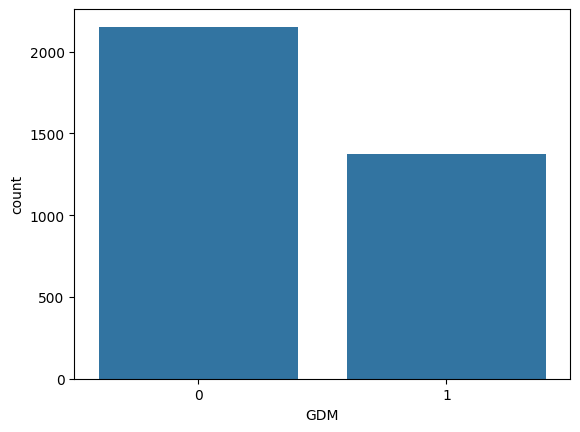

In [24]:
sns.countplot(x='GDM',data = df)
plt.show()

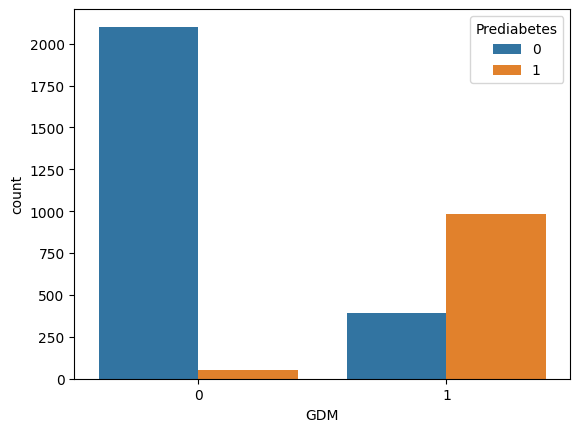

In [25]:
sns.countplot(x='GDM',hue='Prediabetes',data = df)
plt.show()

<Axes: xlabel='Sedentary_Lifestyle', ylabel='BMI'>

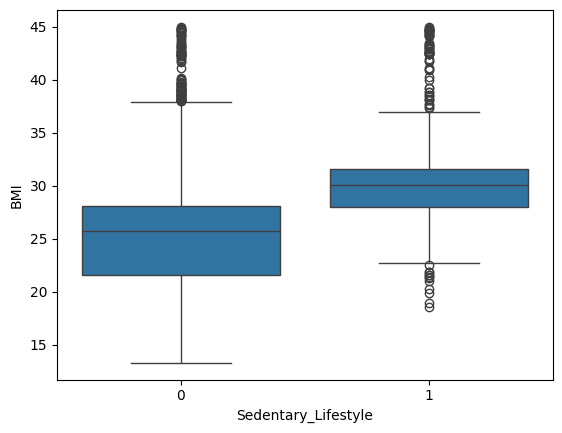

In [26]:
# if prediabetes = 1 at most GDM = 1
sns.boxplot(x='Sedentary_Lifestyle',y='BMI',data = df)

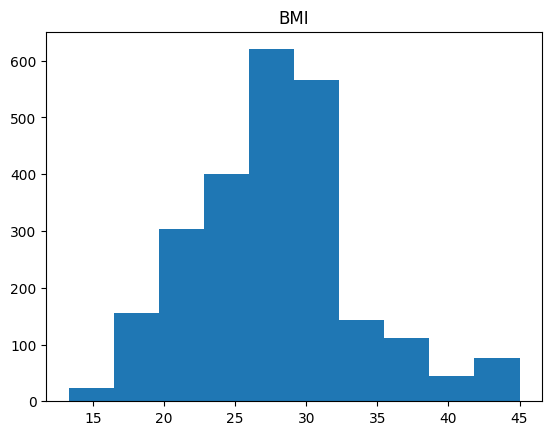

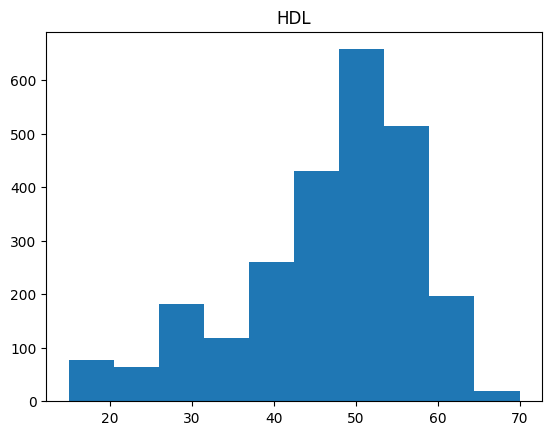

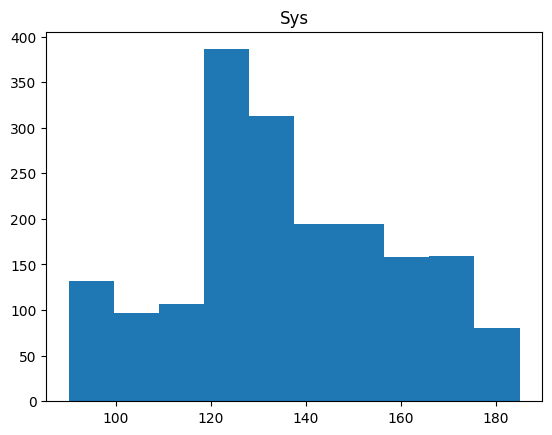

In [27]:
plt.hist(df["BMI"])
plt.title("BMI")
plt.show()

plt.hist(df["HDL"])
plt.title("HDL")
plt.show()

plt.hist(df["Sys"])
plt.title("Sys")
plt.show()

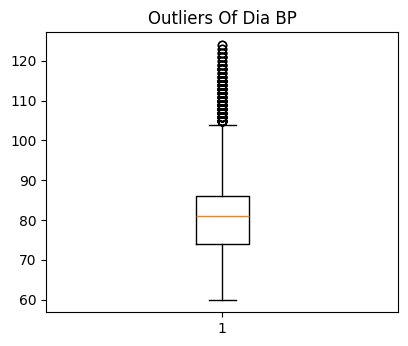

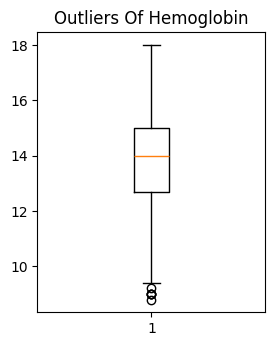

In [28]:

plt.figure(figsize=(10,8))
plt.subplot(2,2,2)
plt.boxplot(df["dia"])
plt.title("Outliers Of Dia BP")
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(2,3,1)
plt.boxplot(df["Hemoglobin"])
plt.title("Outliers Of Hemoglobin")
plt.show()




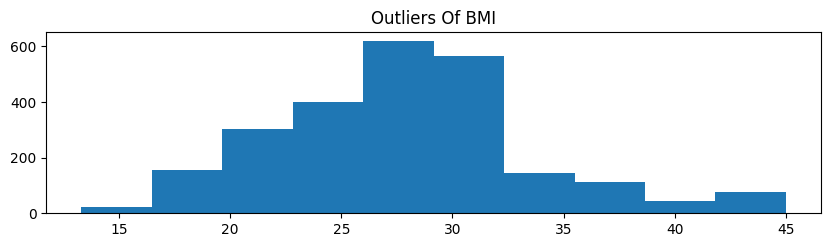

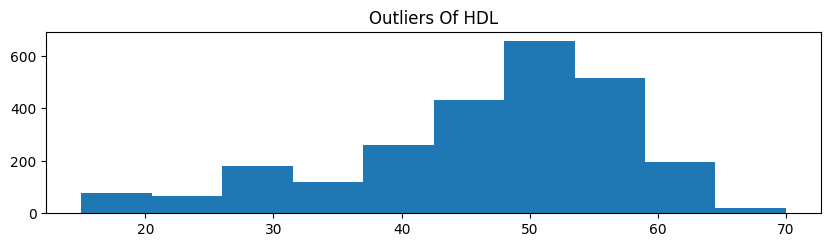

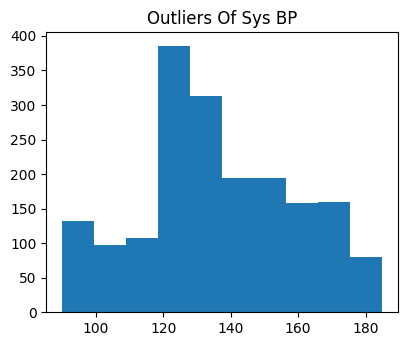

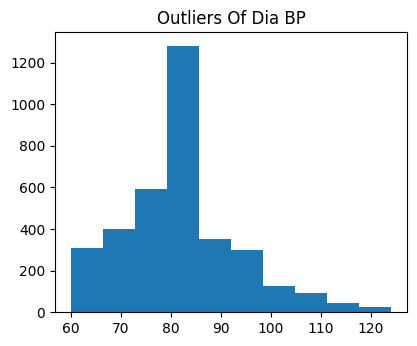

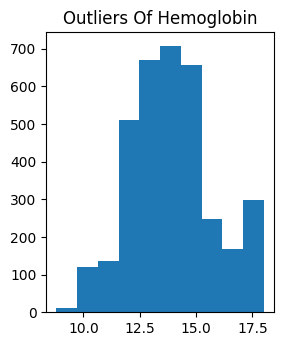

Text(0.5, 1.0, 'Outliers OGTT')

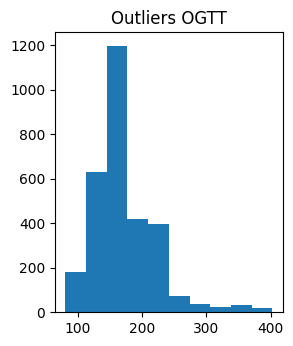

In [29]:
plt.figure(figsize=(10,8))
plt.subplot(3,1,1)
plt.hist(df["BMI"])
plt.title("Outliers Of BMI")
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(3,1,2)
plt.hist(df["HDL"])
plt.title("Outliers Of HDL")
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.hist(df["Sys"])
plt.title("Outliers Of Sys BP")
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(2,2,2)
plt.hist(df["dia"])
plt.title("Outliers Of Dia BP")
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(2,3,1)
plt.hist(df["Hemoglobin"])
plt.title("Outliers Of Hemoglobin")
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(2,3,2)
plt.hist(df["OGTT"])
plt.title("Outliers OGTT")



In [30]:
df["dia"].value_counts()

dia
80     327
81     274
82     272
83     269
75     121
      ... 
122      3
117      3
124      2
120      2
123      2
Name: count, Length: 65, dtype: int64

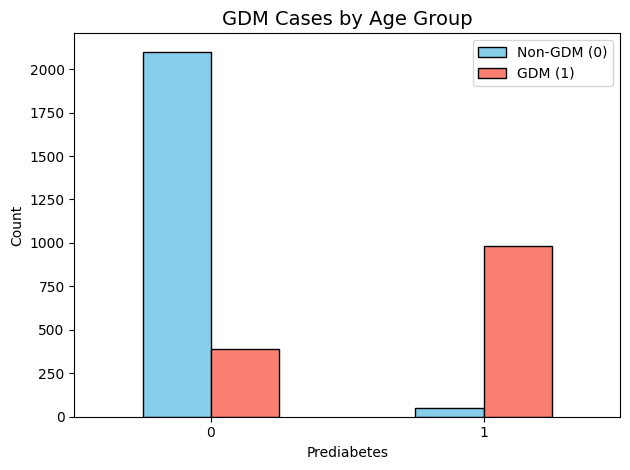

In [31]:
com = df.groupby(["Prediabetes", "GDM"]).size().unstack(fill_value=0)

com.plot(kind="bar", color=["skyblue", "salmon"], edgecolor="black")

plt.title("GDM Cases by Age Group", fontsize=14)
plt.xlabel("Prediabetes")
plt.ylabel("Count")
plt.legend(["Non-GDM (0)", "GDM (1)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


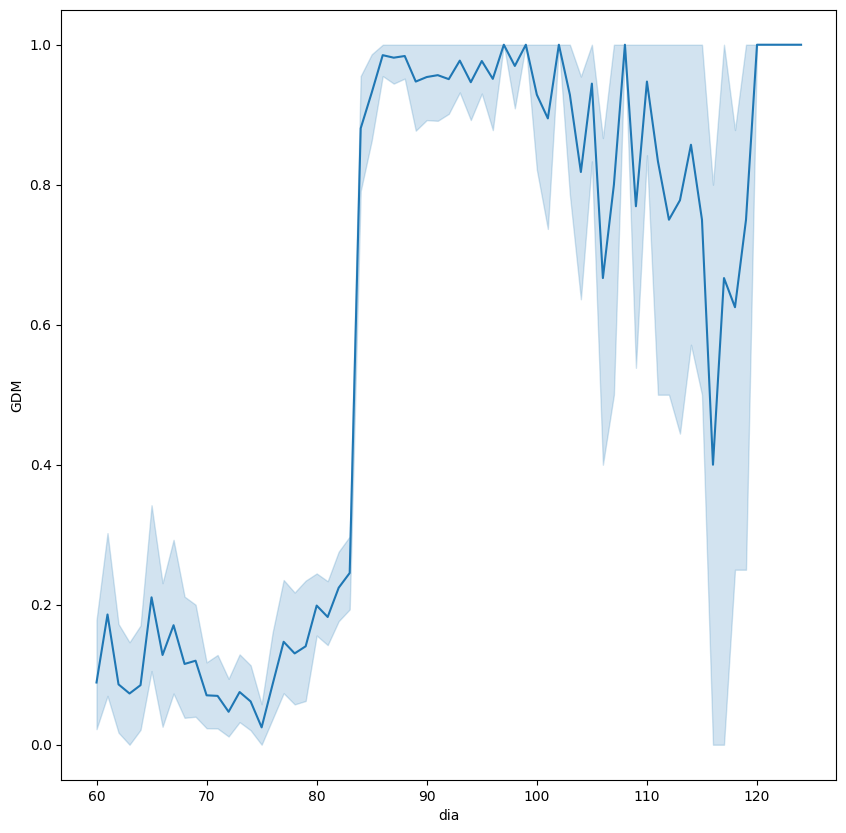

In [32]:
plt.figure(figsize = (10,10))
sns.lineplot(x="dia",y="GDM",data=df)
plt.show()

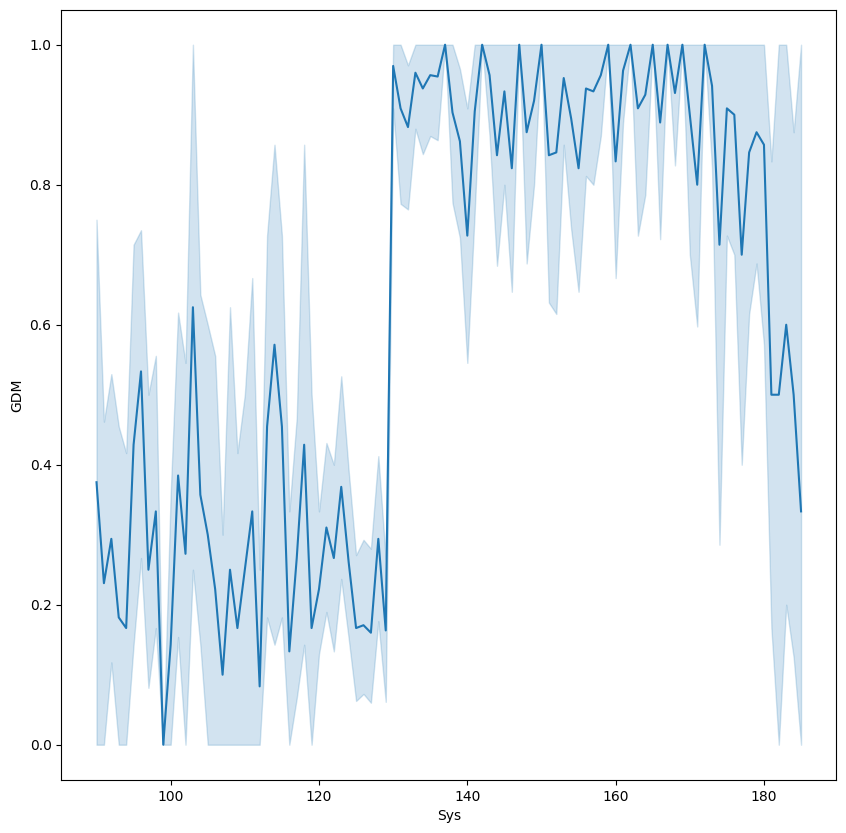

In [33]:
plt.figure(figsize = (10,10))
sns.lineplot(x="Sys",y="GDM",data=df)
plt.show()

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Case Number                      3525 non-null   int64  
 1   Age                              3525 non-null   int64  
 2   No_of_Pregnancy                  3525 non-null   int64  
 3   Gestation_in_previous_Pregnancy  3525 non-null   int64  
 4   BMI                              2444 non-null   float64
 5   HDL                              2524 non-null   float64
 6   Family_History                   3525 non-null   int64  
 7   unexplained_prenetal_loss        3525 non-null   int64  
 8   Large_Child_or_Birth_Default     3525 non-null   int64  
 9   PCOS                             3525 non-null   int64  
 10  Sys                              1820 non-null   float64
 11  dia                              3525 non-null   int64  
 12  OGTT                

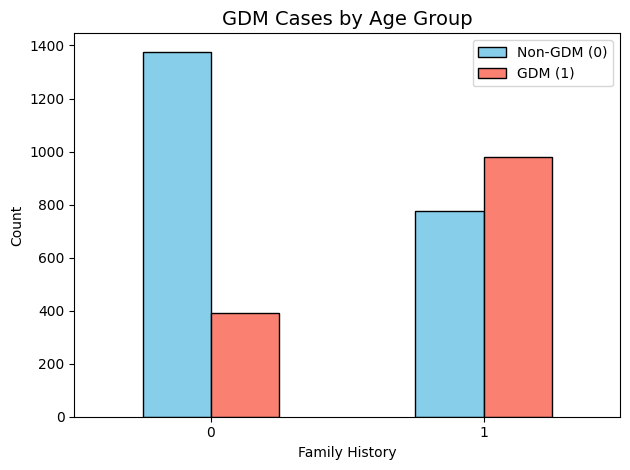

In [35]:
com = df.groupby(["Family_History", "GDM"]).size().unstack(fill_value=0)

com.plot(kind="bar", color=["skyblue", "salmon"], edgecolor="black")

plt.title("GDM Cases by Age Group", fontsize=14)
plt.xlabel("Family History")
plt.ylabel("Count")
plt.legend(["Non-GDM (0)", "GDM (1)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


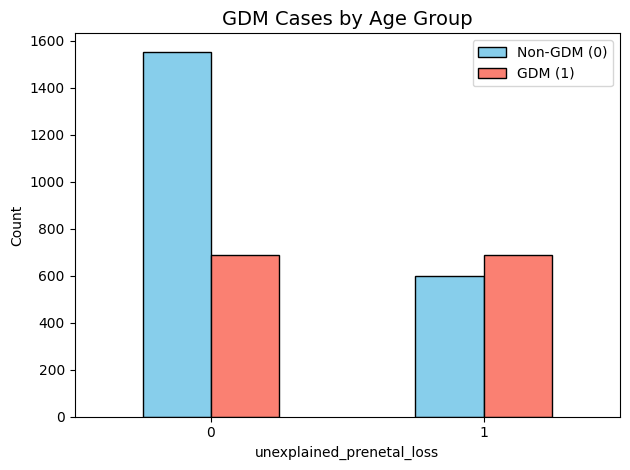

In [36]:
com = df.groupby(["unexplained_prenetal_loss", "GDM"]).size().unstack(fill_value=0)

com.plot(kind="bar", color=["skyblue", "salmon"], edgecolor="black")

plt.title("GDM Cases by Age Group", fontsize=14)
plt.xlabel("unexplained_prenetal_loss")
plt.ylabel("Count")
plt.legend(["Non-GDM (0)", "GDM (1)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


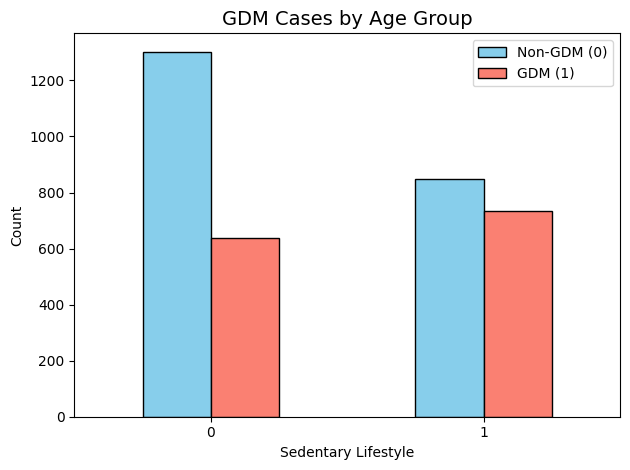

In [37]:
com = df.groupby(["Sedentary_Lifestyle", "GDM"]).size().unstack(fill_value=0)

com.plot(kind="bar", color=["skyblue", "salmon"], edgecolor="black")

plt.title("GDM Cases by Age Group", fontsize=14)
plt.xlabel("Sedentary Lifestyle")
plt.ylabel("Count")
plt.legend(["Non-GDM (0)", "GDM (1)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


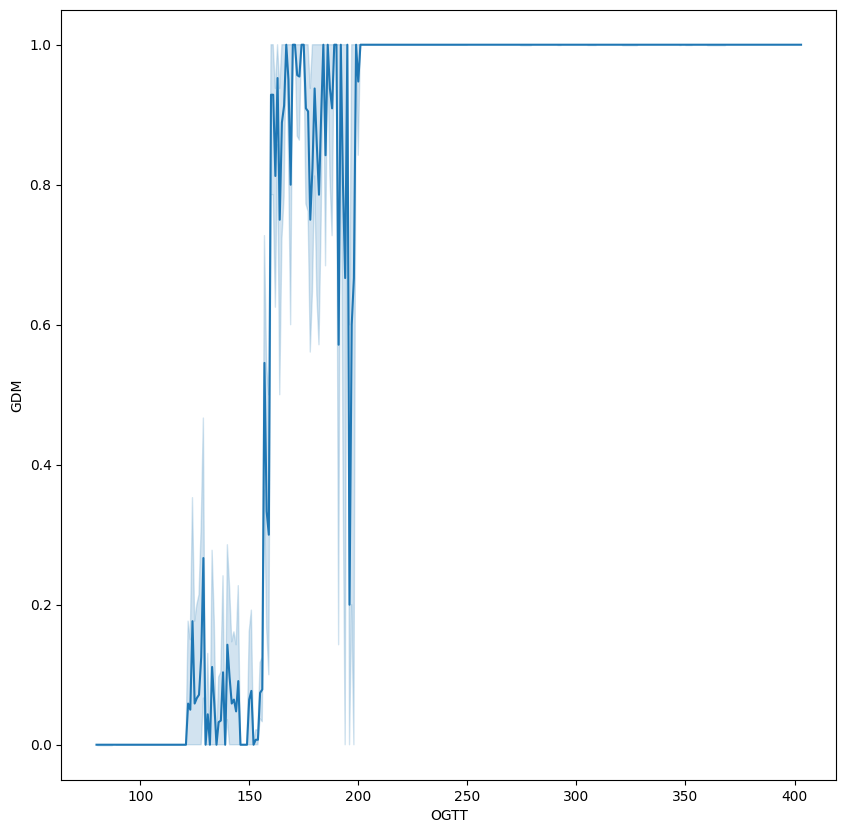

In [38]:
plt.figure(figsize = (10,10))
sns.lineplot(x="OGTT",y="GDM",data=df)
plt.show()

<Axes: xlabel='dia', ylabel='Sys'>

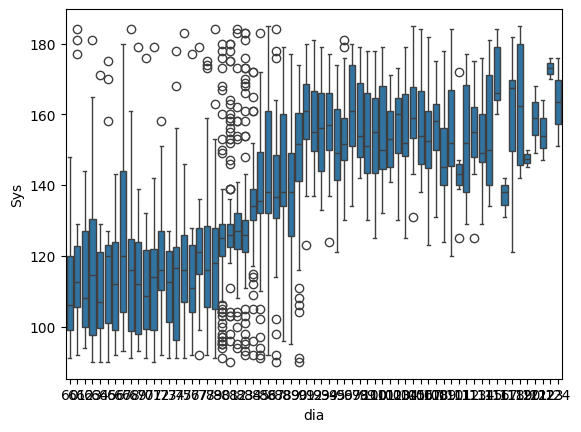

In [39]:

sns.boxplot(x='dia',y='Sys',data = df)

<Axes: xlabel='HDL', ylabel='BMI'>

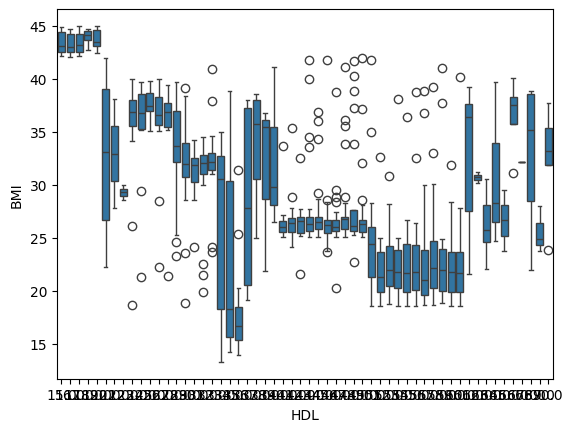

In [40]:
sns.boxplot(x='HDL',y='BMI',data = df)

<Axes: xlabel='Sedentary_Lifestyle', ylabel='HDL'>

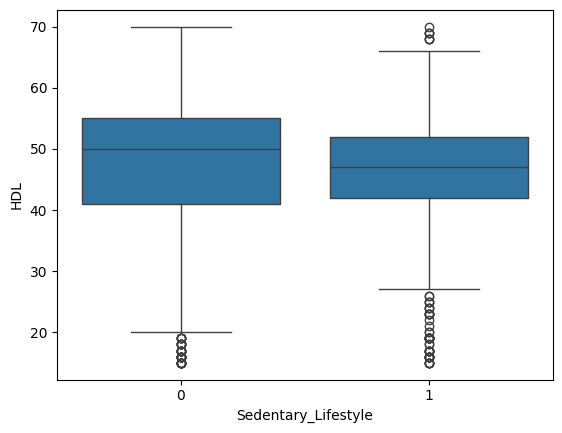

In [41]:
sns.boxplot(x='Sedentary_Lifestyle',y='HDL',data = df)

<Axes: xlabel='GDM', ylabel='HDL'>

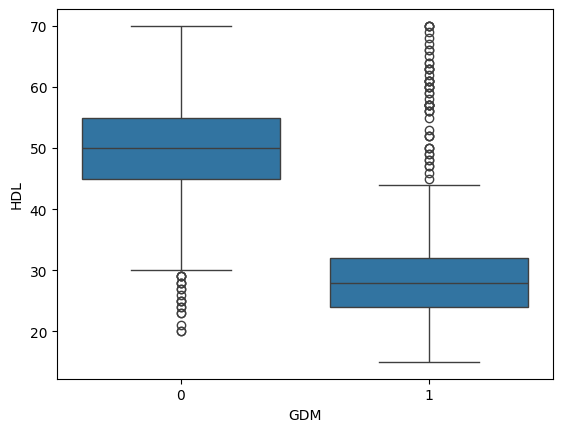

In [42]:
sns.boxplot(x='GDM',y='HDL',data = df)

<Axes: xlabel='HDL', ylabel='BMI'>

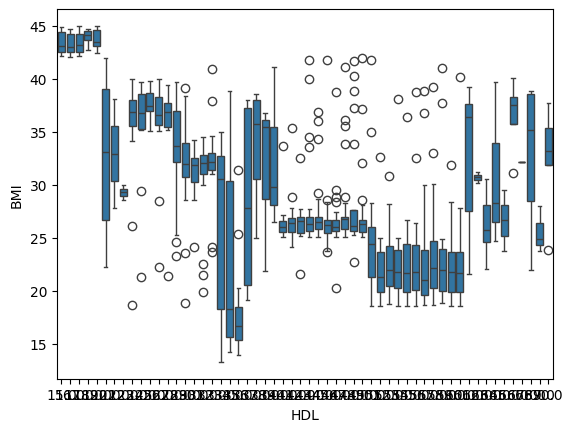

In [43]:
sns.boxplot(x='HDL',y='BMI',data = df)

<Axes: xlabel='HDL', ylabel='Age'>

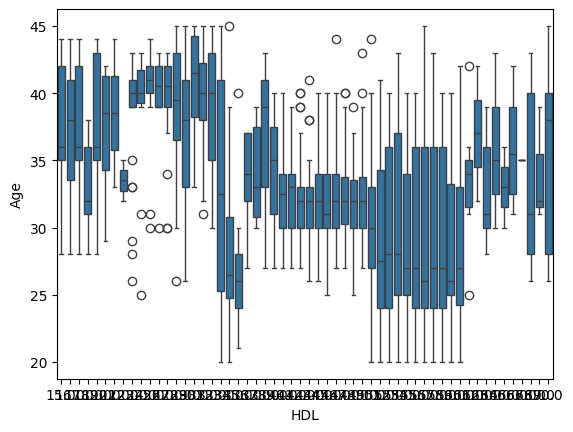

In [44]:
sns.boxplot(x='HDL',y='Age',data = df)

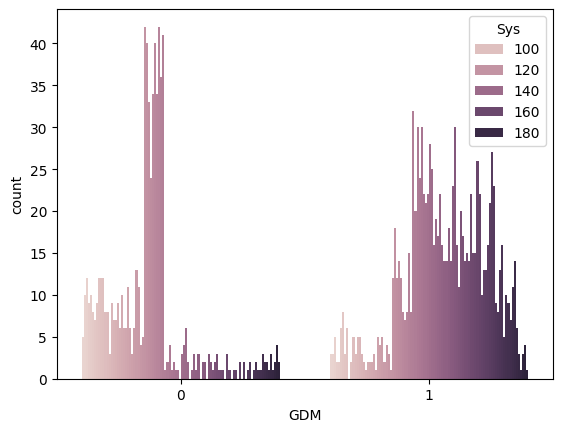

In [45]:
sns.countplot(x='GDM',hue='Sys',data = df)
plt.show()

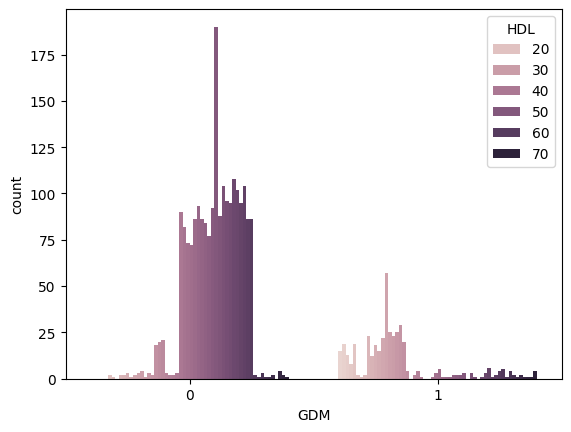

In [46]:
sns.countplot(x='GDM',hue='HDL',data = df)
plt.show()


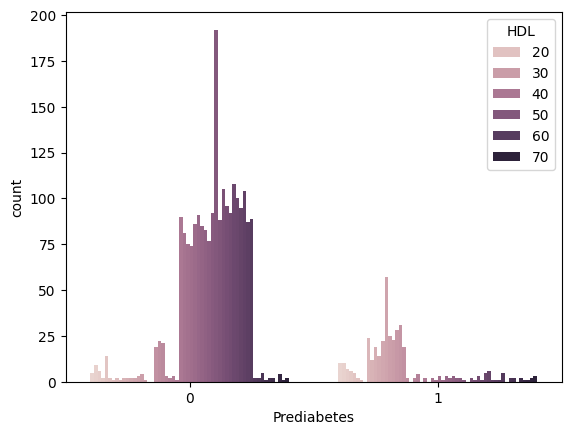

In [47]:
sns.countplot(x='Prediabetes',hue='HDL',data = df)
plt.show()

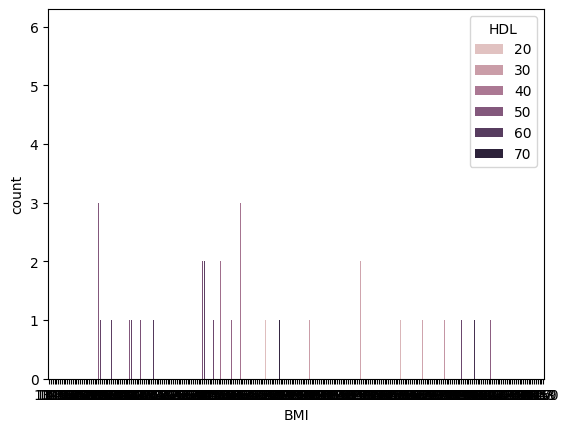

In [48]:

sns.countplot(x='BMI',hue='HDL',data = df)
plt.show()

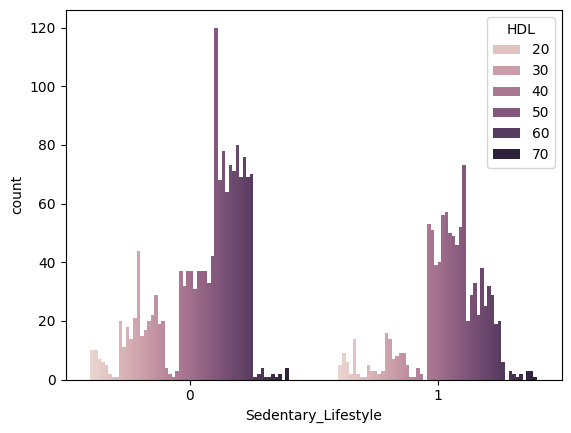

In [49]:
sns.countplot(x='Sedentary_Lifestyle',hue='HDL',data = df)
plt.show()

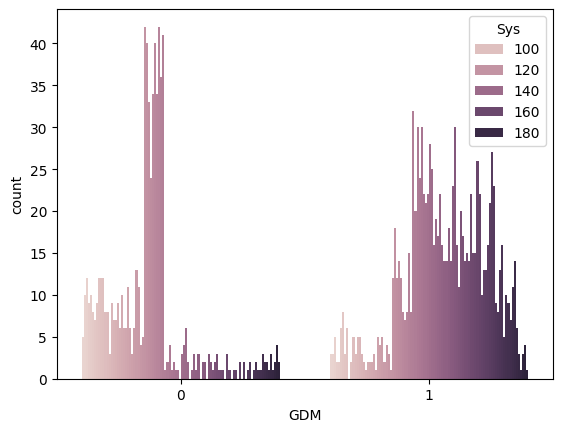

In [50]:
sns.countplot(x='GDM',hue='Sys',data = df)
plt.show()

<Axes: xlabel='OGTT', ylabel='BMI'>

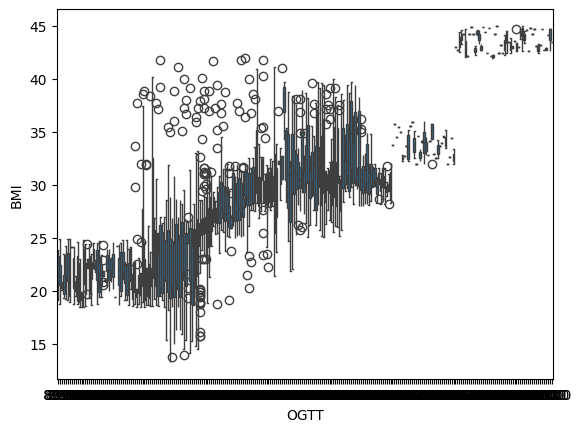

In [51]:
sns.boxplot(x='OGTT',y='BMI',data = df)

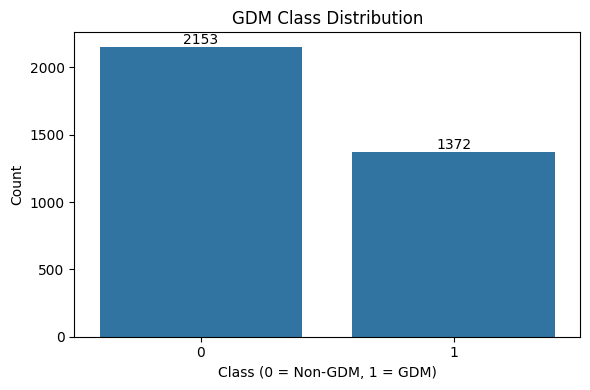

In [52]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x="GDM")
ax.set_title("GDM Class Distribution")
ax.set_xlabel("Class (0 = Non-GDM, 1 = GDM)")
ax.set_ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",(p.get_x() + p.get_width()/2, p.get_height()),ha='center', va='bottom')

plt.tight_layout()
plt.show()

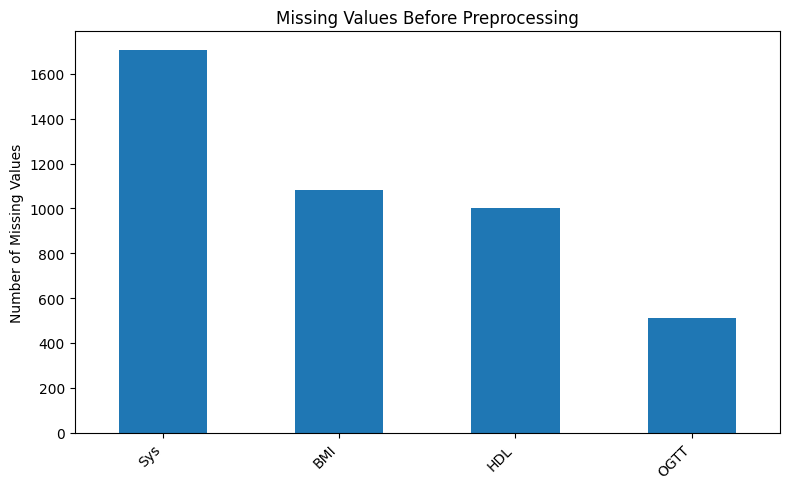

In [53]:
missing_before = df.isna().sum().sort_values(ascending=False)
missing_before = missing_before[missing_before > 0]

plt.figure(figsize=(8,5))
missing_before.plot(kind="bar")
plt.title("Missing Values Before Preprocessing")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Preprocessing


In [54]:
#1- feature selection
#2- Null Values
#3- outliers 
#4- Splitting

### 1- feature selection

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Case Number                      3525 non-null   int64  
 1   Age                              3525 non-null   int64  
 2   No_of_Pregnancy                  3525 non-null   int64  
 3   Gestation_in_previous_Pregnancy  3525 non-null   int64  
 4   BMI                              2444 non-null   float64
 5   HDL                              2524 non-null   float64
 6   Family_History                   3525 non-null   int64  
 7   unexplained_prenetal_loss        3525 non-null   int64  
 8   Large_Child_or_Birth_Default     3525 non-null   int64  
 9   PCOS                             3525 non-null   int64  
 10  Sys                              1820 non-null   float64
 11  dia                              3525 non-null   int64  
 12  OGTT                

In [56]:
df.drop(columns = ['Case Number'],inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              3525 non-null   int64  
 1   No_of_Pregnancy                  3525 non-null   int64  
 2   Gestation_in_previous_Pregnancy  3525 non-null   int64  
 3   BMI                              2444 non-null   float64
 4   HDL                              2524 non-null   float64
 5   Family_History                   3525 non-null   int64  
 6   unexplained_prenetal_loss        3525 non-null   int64  
 7   Large_Child_or_Birth_Default     3525 non-null   int64  
 8   PCOS                             3525 non-null   int64  
 9   Sys                              1820 non-null   float64
 10  dia                              3525 non-null   int64  
 11  OGTT                             3012 non-null   float64
 12  Hemoglobin          

In [57]:
df.head()

,Age,No_of_Pregnancy,Gestation_in_previous_Pregnancy,BMI,HDL,Family_History,unexplained_prenetal_loss,Large_Child_or_Birth_Default,PCOS,Sys,dia,OGTT,Hemoglobin,Sedentary_Lifestyle,Prediabetes,GDM
0,22,2,1,NaN,55.0,0,0,0,0,102.0,69,NaN,12.0,0,0,0
1,26,2,1,NaN,53.0,0,0,0,0,101.0,63,NaN,12.4,0,0,0
2,29,1,0,NaN,50.0,0,0,0,0,118.0,79,NaN,14.3,0,0,0
3,28,2,1,NaN,51.0,0,0,0,0,99.0,70,NaN,15.0,0,0,0
4,21,2,1,NaN,52.0,0,0,0,0,116.0,65,NaN,15.0,0,0,0


### 2-Handle Null Values

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              3525 non-null   int64  
 1   No_of_Pregnancy                  3525 non-null   int64  
 2   Gestation_in_previous_Pregnancy  3525 non-null   int64  
 3   BMI                              2444 non-null   float64
 4   HDL                              2524 non-null   float64
 5   Family_History                   3525 non-null   int64  
 6   unexplained_prenetal_loss        3525 non-null   int64  
 7   Large_Child_or_Birth_Default     3525 non-null   int64  
 8   PCOS                             3525 non-null   int64  
 9   Sys                              1820 non-null   float64
 10  dia                              3525 non-null   int64  
 11  OGTT                             3012 non-null   float64
 12  Hemoglobin          

<Axes: xlabel='Prediabetes', ylabel='BMI'>

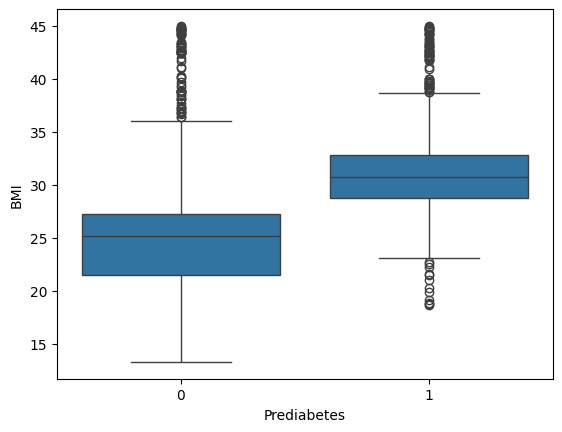

In [59]:
sns.boxplot(x='Prediabetes',y='BMI',data = df)

In [60]:
# if Prediabetes=0 BMI between 23 - 27  else  BMI between 29 - 33
rng = np.random.default_rng(42)
def imput_nulls_BMI(cols):
    BMI=cols[0]
    target=cols[1]
    if pd.isnull(BMI):
        if target == 0:
            return float(rng.uniform(23, 27))
        else :
            return float(rng.uniform(29, 33))
    else:
        return BMI
df['BMI']=df[['BMI','Prediabetes']].apply(imput_nulls_BMI,axis=1)
df.isna().sum()

Age                                   0
No_of_Pregnancy                       0
Gestation_in_previous_Pregnancy       0
BMI                                   0
HDL                                1001
Family_History                        0
unexplained_prenetal_loss             0
Large_Child_or_Birth_Default          0
PCOS                                  0
Sys                                1705
dia                                   0
OGTT                                513
Hemoglobin                            0
Sedentary_Lifestyle                   0
Prediabetes                           0
GDM                                   0
dtype: int64

<Axes: xlabel='Prediabetes', ylabel='HDL'>

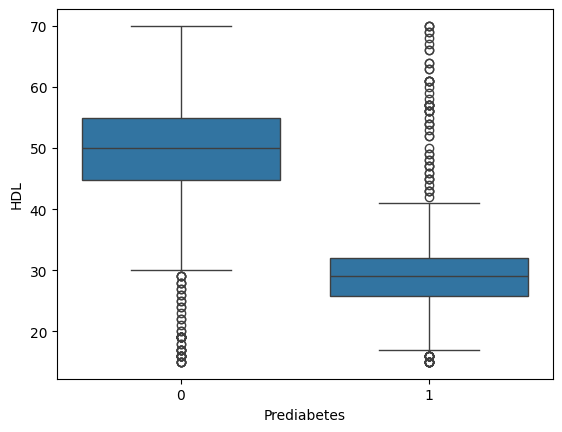

In [61]:
sns.boxplot(x='Prediabetes',y='HDL',data = df)

In [62]:
# if Prediabetes=0 HDL between 46 - 55  else  HDL between 27 - 32
rng = np.random.default_rng(42)
def imput_nulls_HDL(cols):
    HDL=cols[0]
    target=cols[1]
    if pd.isnull(HDL):
        if target == 0:
            return float(rng.uniform(46, 55))
        else :
            return float(rng.uniform(27, 32))
    else:
        return HDL
df['HDL']=df[['HDL','Prediabetes']].apply(imput_nulls_HDL,axis=1)
df.isna().sum()

Age                                   0
No_of_Pregnancy                       0
Gestation_in_previous_Pregnancy       0
BMI                                   0
HDL                                   0
Family_History                        0
unexplained_prenetal_loss             0
Large_Child_or_Birth_Default          0
PCOS                                  0
Sys                                1705
dia                                   0
OGTT                                513
Hemoglobin                            0
Sedentary_Lifestyle                   0
Prediabetes                           0
GDM                                   0
dtype: int64

<Axes: xlabel='Prediabetes', ylabel='Sys'>

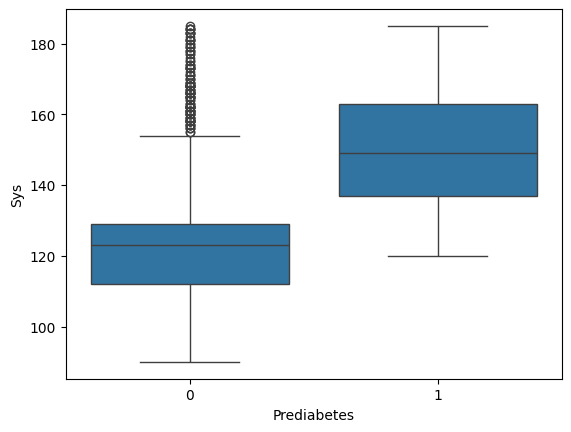

In [63]:
sns.boxplot(x='Prediabetes',y='Sys',data = df)

In [64]:
# if Prediabetes=0 Sys between 113 - 127  else  Sys between 139 - 162
rng = np.random.default_rng(42)
def imput_nulls_Sys(cols):
    Sys=cols[0]
    target=cols[1]
    if pd.isnull(Sys):
        if target == 0:
            return float(rng.uniform(113, 127))
        else :
            return float(rng.uniform(139, 162))
    else:
        return Sys
df['Sys']=df[['Sys','Prediabetes']].apply(imput_nulls_Sys,axis=1)
df.isna().sum()

Age                                  0
No_of_Pregnancy                      0
Gestation_in_previous_Pregnancy      0
BMI                                  0
HDL                                  0
Family_History                       0
unexplained_prenetal_loss            0
Large_Child_or_Birth_Default         0
PCOS                                 0
Sys                                  0
dia                                  0
OGTT                               513
Hemoglobin                           0
Sedentary_Lifestyle                  0
Prediabetes                          0
GDM                                  0
dtype: int64

<Axes: xlabel='Prediabetes', ylabel='OGTT'>

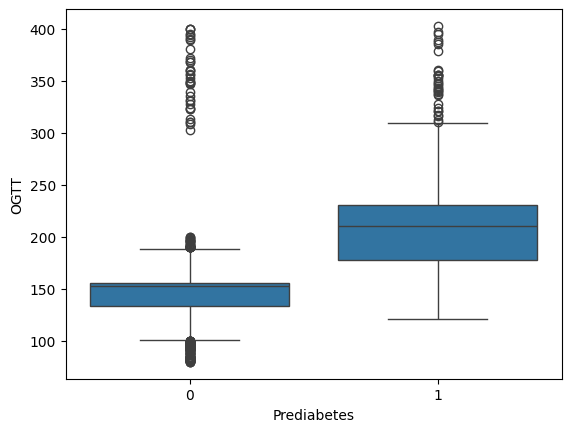

In [65]:
sns.boxplot(x='Prediabetes',y='OGTT',data = df)

In [66]:
# if Prediabetes=0 OGTT between 137 - 157  else  OGTT between 180 - 230
rng = np.random.default_rng(42)
def imput_nulls_OGTT(cols):
    OGTT=cols[0]
    target=cols[1]
    if pd.isnull(OGTT):
        if target == 0:
            return float(rng.uniform(137, 157))
        else :
            return float(rng.uniform(180, 230))
    else:
        return OGTT
df['OGTT']=df[['OGTT','Prediabetes']].apply(imput_nulls_OGTT,axis=1)
df.isna().sum()

Age                                0
No_of_Pregnancy                    0
Gestation_in_previous_Pregnancy    0
BMI                                0
HDL                                0
Family_History                     0
unexplained_prenetal_loss          0
Large_Child_or_Birth_Default       0
PCOS                               0
Sys                                0
dia                                0
OGTT                               0
Hemoglobin                         0
Sedentary_Lifestyle                0
Prediabetes                        0
GDM                                0
dtype: int64

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              3525 non-null   int64  
 1   No_of_Pregnancy                  3525 non-null   int64  
 2   Gestation_in_previous_Pregnancy  3525 non-null   int64  
 3   BMI                              3525 non-null   float64
 4   HDL                              3525 non-null   float64
 5   Family_History                   3525 non-null   int64  
 6   unexplained_prenetal_loss        3525 non-null   int64  
 7   Large_Child_or_Birth_Default     3525 non-null   int64  
 8   PCOS                             3525 non-null   int64  
 9   Sys                              3525 non-null   float64
 10  dia                              3525 non-null   int64  
 11  OGTT                             3525 non-null   float64
 12  Hemoglobin          

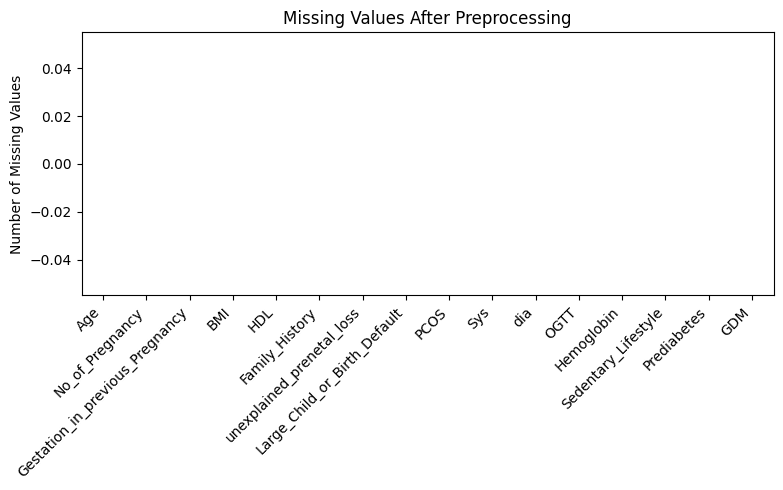

In [68]:
missing_after = df.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
missing_after.plot(kind="bar")
plt.title("Missing Values After Preprocessing")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 3- Outliers

In [69]:
df.describe()

,Age,No_of_Pregnancy,Gestation_in_previous_Pregnancy,BMI,HDL,Family_History,unexplained_prenetal_loss,Large_Child_or_Birth_Default,PCOS,Sys,dia,OGTT,Hemoglobin,Sedentary_Lifestyle,Prediabetes,GDM
count,3525.000000,3525.000000,3525.000000,3525.000000,3525.000000,3525.000000,3525.000000,3525.00000,3525.000000,3525.000000,3525.000000,3525.000000,3525.000000,3525.000000,3525.000000,3525.000000
mean,32.581277,2.076312,0.960851,26.977000,43.742560,0.498156,0.364823,0.35773,0.264681,130.349305,81.538156,167.248454,13.959801,0.449645,0.293050,0.389220
std,6.169107,0.838637,0.722313,4.979129,11.482710,0.500068,0.481449,0.47940,0.441226,19.144122,11.379758,45.352655,1.863969,0.497529,0.455226,0.487643
min,20.000000,1.000000,0.000000,13.300000,15.000000,0.000000,0.000000,0.00000,0.000000,90.000000,60.000000,80.000000,8.800000,0.000000,0.000000,0.000000
25%,28.000000,1.000000,0.000000,24.112453,31.303595,0.000000,0.000000,0.00000,0.000000,118.280026,74.000000,142.000000,12.700000,0.000000,0.000000,0.000000
50%,32.000000,2.000000,1.000000,26.109373,47.000000,0.000000,0.000000,0.00000,0.000000,124.497231,81.000000,154.940668,14.000000,0.000000,0.000000,0.000000
75%,37.000000,3.000000,1.000000,29.600000,53.000000,1.000000,1.000000,1.00000,1.000000,143.000000,86.000000,184.000000,15.000000,1.000000,1.000000,1.000000
max,45.000000,4.000000,2.000000,45.000000,70.000000,1.000000,1.000000,1.00000,1.000000,185.000000,124.000000,403.000000,18.000000,1.000000,1.000000,1.000000


<Axes: xlabel='OGTT'>

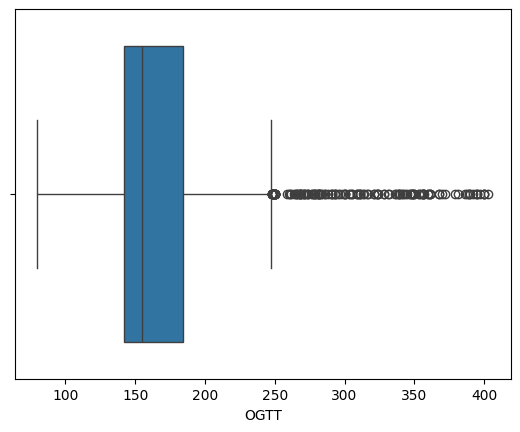

In [70]:
sns.boxplot(x= 'OGTT',data = df)

<Axes: xlabel='dia'>

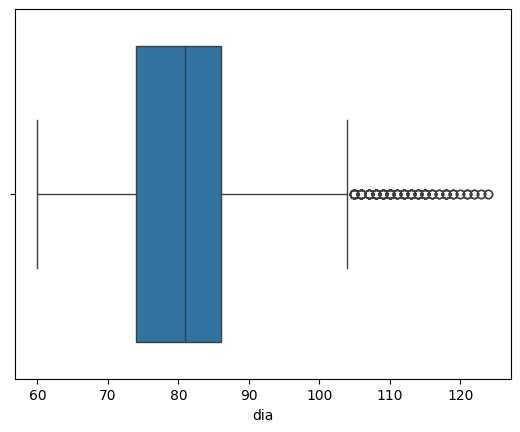

In [71]:
sns.boxplot(x= 'dia',data = df)

<Axes: xlabel='Sys'>

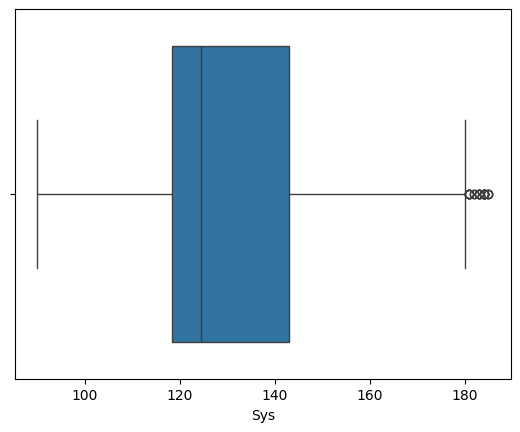

In [72]:
sns.boxplot(x= 'Sys',data = df)

<Axes: xlabel='HDL'>

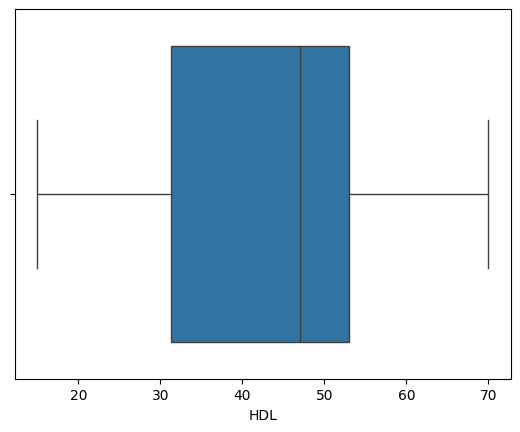

In [73]:
sns.boxplot(x= 'HDL',data = df)

<Axes: xlabel='BMI'>

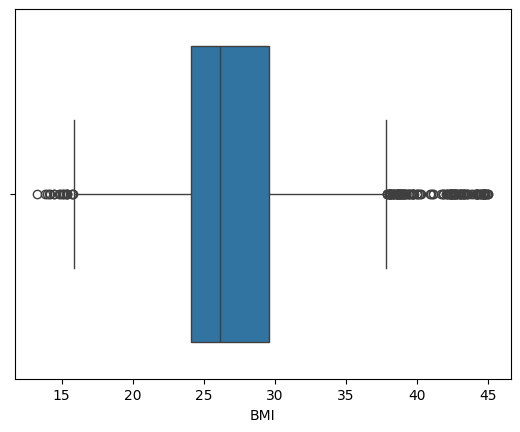

In [74]:
sns.boxplot(x= 'BMI',data = df)

In [75]:
X = df.drop(columns=['GDM'])
y = df['GDM']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

#scaler = StandardScaler()
#x_train.loc[:, scale_cols] = scaler.fit_transform(x_train[scale_cols]) 
#x_test.loc[:,  scale_cols] = scaler.transform(x_test[scale_cols])      
x_train.head()


,Age,No_of_Pregnancy,Gestation_in_previous_Pregnancy,BMI,HDL,Family_History,unexplained_prenetal_loss,Large_Child_or_Birth_Default,PCOS,Sys,dia,OGTT,Hemoglobin,Sedentary_Lifestyle,Prediabetes
3244,31,2,2,35.700000,28.000000,1,0,1,1,153.000000,81,260.0,13.3,1,1
2492,25,3,2,30.500000,30.937161,1,1,1,1,165.000000,86,232.0,15.7,1,1
1967,32,3,1,20.700000,53.000000,0,0,0,0,117.817975,75,98.0,12.3,0,0
1040,30,3,1,23.366895,47.000000,1,0,1,0,123.284695,82,156.0,13.0,1,0
1201,24,1,0,19.600000,59.000000,0,0,0,0,123.089743,75,121.0,16.0,0,0


In [76]:
cols = ['Sys','dia','HDL','BMI','OGTT']
q1 = x_train[cols].quantile(0.25)
q3 = x_train[cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
mask_train = ((x_train[cols] >= lower) & (x_train[cols] <= upper)).all(axis=1)
x_train = x_train[mask_train]
y_train = y_train[mask_train]

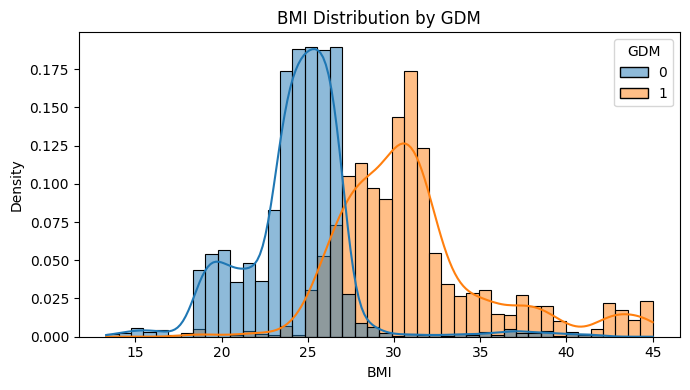

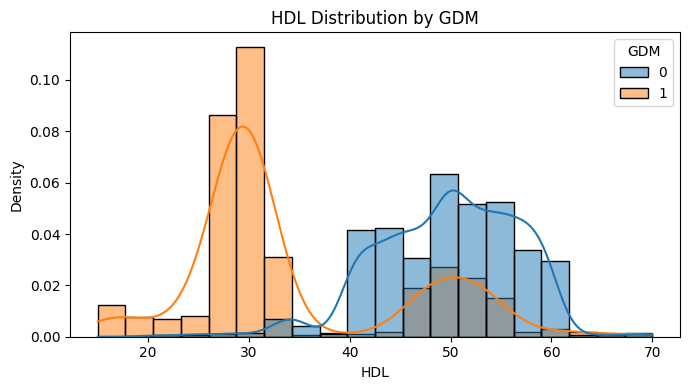

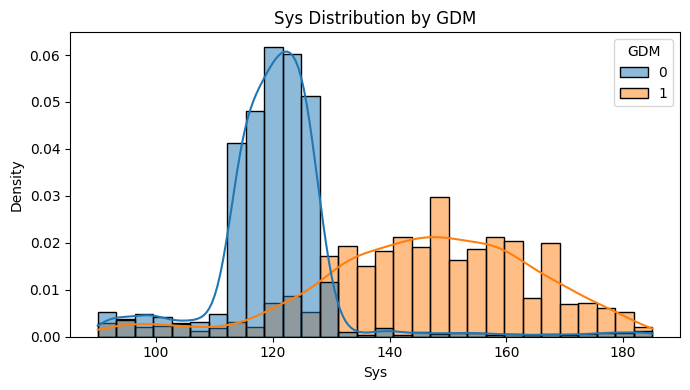

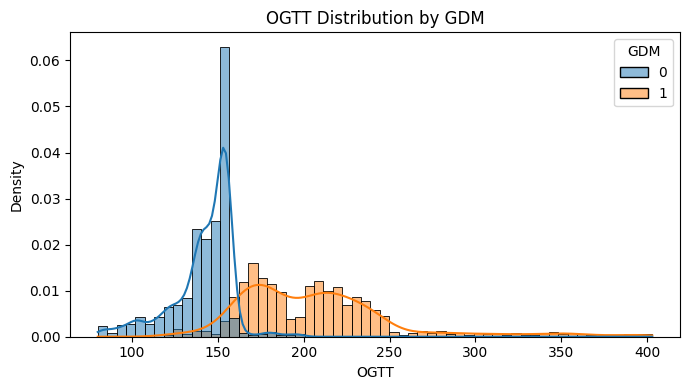

In [77]:
key_features = ["BMI", "HDL", "Sys", "OGTT"]

for col in key_features:
    plt.figure(figsize=(7,4))
    sns.histplot(data=df, x=col, hue="GDM", kde=True, stat="density", common_norm=False)
    plt.title(f"{col} Distribution by GDM")
    plt.tight_layout()
    plt.show()

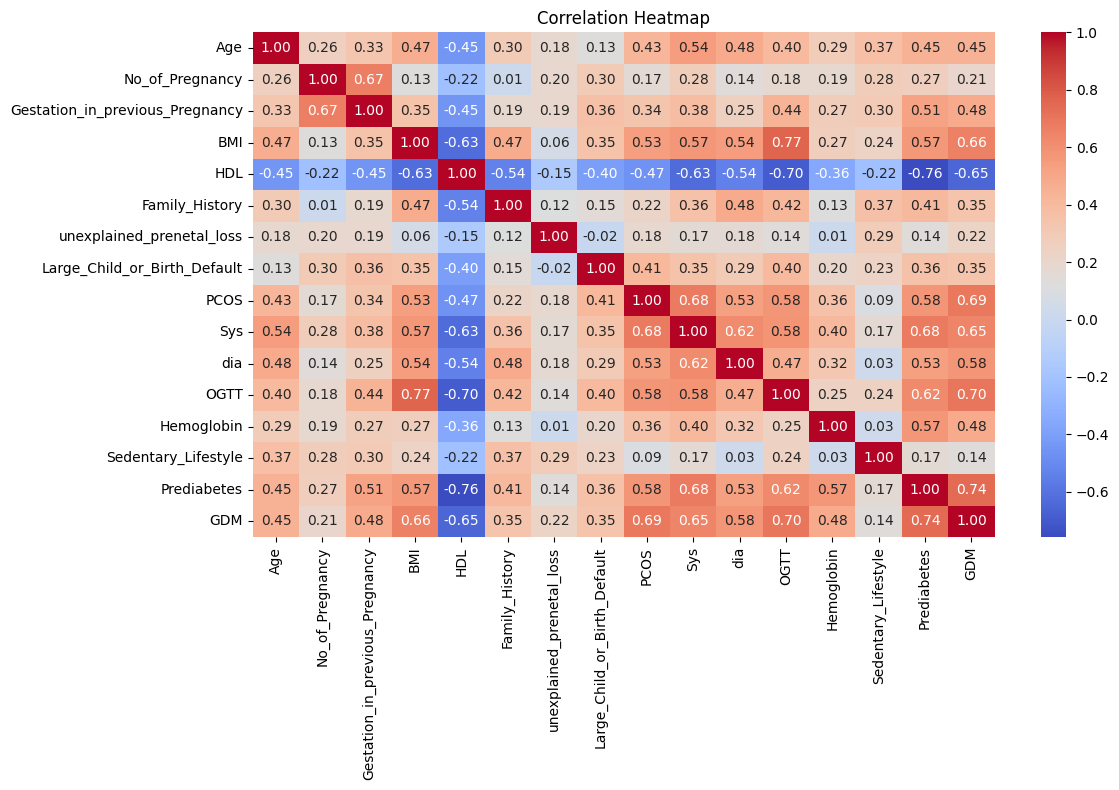

In [78]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

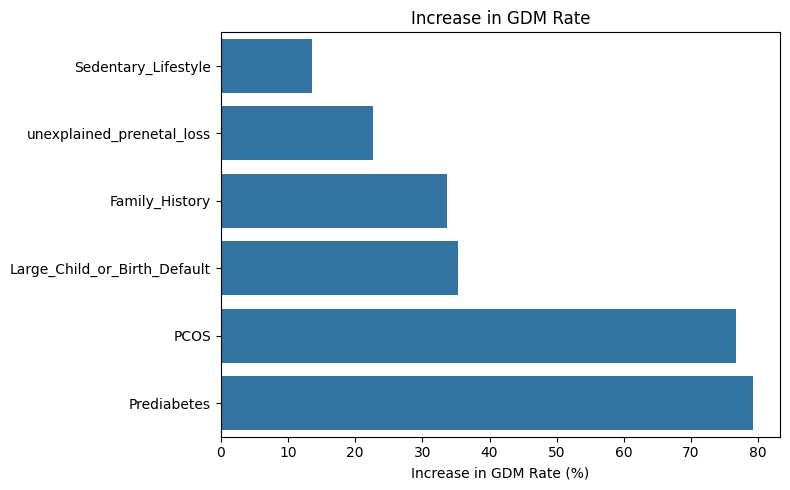

,Feature,Rate_when_0,Rate_when_1,Increase
3,Sedentary_Lifestyle,32.835052,46.372240,13.537188
5,unexplained_prenetal_loss,30.638678,53.343701,22.705023
1,Family_History,22.159412,55.808656,33.649244
4,Large_Child_or_Birth_Default,26.280919,61.617764,35.336845
2,PCOS,18.634259,95.284030,76.649771
0,Prediabetes,15.690209,94.966118,79.275909


In [79]:
binary_cols = [
    "Prediabetes",
    "Family_History",
    "PCOS",
    "Sedentary_Lifestyle",
    "Large_Child_or_Birth_Default",
    "unexplained_prenetal_loss"
]

rate_rows = []
for col in binary_cols:
    grp = df.groupby(col)["GDM"].mean() * 100
    rate_rows.append({
        "Feature": col,
        "Rate_when_0": grp.get(0, np.nan),
        "Rate_when_1": grp.get(1, np.nan),
        "Increase": grp.get(1, np.nan) - grp.get(0, np.nan)
    })

risk_df = pd.DataFrame(rate_rows).sort_values("Increase")

plt.figure(figsize=(8,5))
sns.barplot(data=risk_df, x="Increase", y="Feature")
plt.title("Increase in GDM Rate")
plt.xlabel("Increase in GDM Rate (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

risk_df

### Splitting

In [80]:
print('x_train shape: ',x_train.shape)
print('y_train shape: ',y_train.shape)
print('--'*20)
print('x_test shape: ',x_test.shape)

print('y_test shape: ',y_test.shape)

x_train shape:  (2506, 15)
y_train shape:  (2506,)
----------------------------------------
x_test shape:  (705, 15)
y_test shape:  (705,)


# Classification

## Logistic

#### tuning model

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

logistic_param_grid = {
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear", "saga"],
    "C": [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 5, 10],
    "class_weight": ["balanced", None]
}

logistic_tuned = tune_model_with_threshold(
    X_train=x_train,
    y_train=y_train,
    model_builder=lambda **params: LogisticRegression(
        random_state=1,
        max_iter=5000,
        **params
    ),
    param_grid=logistic_param_grid,
    scaler_class=StandardScaler,
    target_recall=0.985,
    selection_metric="accuracy",
    cv_splits=5,
    random_state=1,
    verbose=True
)

Done 1/60 | Recall=0.9893 | Accuracy=0.8903 | Threshold=0.32
Done 2/60 | Recall=0.9881 | Accuracy=0.8907 | Threshold=0.38
Done 3/60 | Recall=0.9893 | Accuracy=0.8903 | Threshold=0.32
Done 4/60 | Recall=0.9881 | Accuracy=0.8516 | Threshold=0.21
Done 5/60 | Recall=0.9893 | Accuracy=0.8444 | Threshold=0.33
Done 6/60 | Recall=0.9881 | Accuracy=0.8516 | Threshold=0.21
Done 7/60 | Recall=0.9881 | Accuracy=0.9777 | Threshold=0.36
Done 8/60 | Recall=0.9881 | Accuracy=0.9769 | Threshold=0.41
Done 9/60 | Recall=0.9881 | Accuracy=0.9777 | Threshold=0.36
Done 10/60 | Recall=0.9881 | Accuracy=0.9677 | Threshold=0.23
Done 11/60 | Recall=0.9869 | Accuracy=0.9681 | Threshold=0.33
Done 12/60 | Recall=0.9881 | Accuracy=0.9677 | Threshold=0.23
Done 13/60 | Recall=0.9857 | Accuracy=0.9848 | Threshold=0.49
Done 14/60 | Recall=0.9881 | Accuracy=0.9844 | Threshold=0.47
Done 15/60 | Recall=0.9857 | Accuracy=0.9848 | Threshold=0.49
Done 16/60 | Recall=0.9857 | Accuracy=0.9840 | Threshold=0.35
Done 17/60 | Reca

,param_id,C,class_weight,penalty,solver,best_threshold,hit_target_recall,CV_TP,CV_TN,CV_FP,CV_FN,CV_accuracy,CV_recall,CV_precision,CV_specificity,CV_f1,CV_f2,CV_roc_auc,CV_pr_auc
57,params_58,10.0,None,l2,lbfgs,0.54,True,826,1649,19,12,0.98763,0.98568,0.977515,0.988609,0.981581,0.984036,0.992252,0.986292


### Best Model

In [94]:
logistic_test_metrics, logistic_predictions_df = evaluate_tuned_model(
    tuned_object=logistic_tuned,
    X=x_test,
    y=y_test,
    dataset_name="Test"
)

logistic_predictions_df.head()

Test Metrics
----------------------------------------
dataset: Test
threshold: 0.5400
TP: 268
TN: 409
FP: 22
FN: 6
accuracy: 0.9603
recall: 0.9781
precision: 0.9241
specificity: 0.9490
f1: 0.9504
f2: 0.9668
roc_auc: 0.9851
pr_auc: 0.9745

Classification Report:
              precision    recall  f1-score   support

     Non GDM       0.99      0.95      0.97       431
         GDM       0.92      0.98      0.95       274

    accuracy                           0.96       705
   macro avg       0.95      0.96      0.96       705
weighted avg       0.96      0.96      0.96       705



,Age,No_of_Pregnancy,Gestation_in_previous_Pregnancy,BMI,HDL,Family_History,unexplained_prenetal_loss,Large_Child_or_Birth_Default,PCOS,Sys,dia,OGTT,Hemoglobin,Sedentary_Lifestyle,Prediabetes,Actual_GDM,GDM_Probability,Predicted_GDM
1366,26,1,0,21.400000,52.000000,0,0,0,0,114.548813,72,128.0,15.0,0,0,0,0.000260,0
753,38,3,1,24.919454,53.000000,0,1,0,0,122.411361,61,154.0,14.0,1,0,0,0.007526,0
2885,34,3,2,27.500000,27.655543,0,1,1,0,139.000000,81,174.0,16.9,0,1,1,0.991058,1
3252,36,1,0,44.700000,16.000000,1,0,1,0,140.000000,95,311.0,12.0,1,0,1,1.000000,1
601,32,2,1,26.045730,40.000000,1,1,0,0,122.763152,82,124.0,13.0,1,0,0,0.003209,0


#### Model Plots

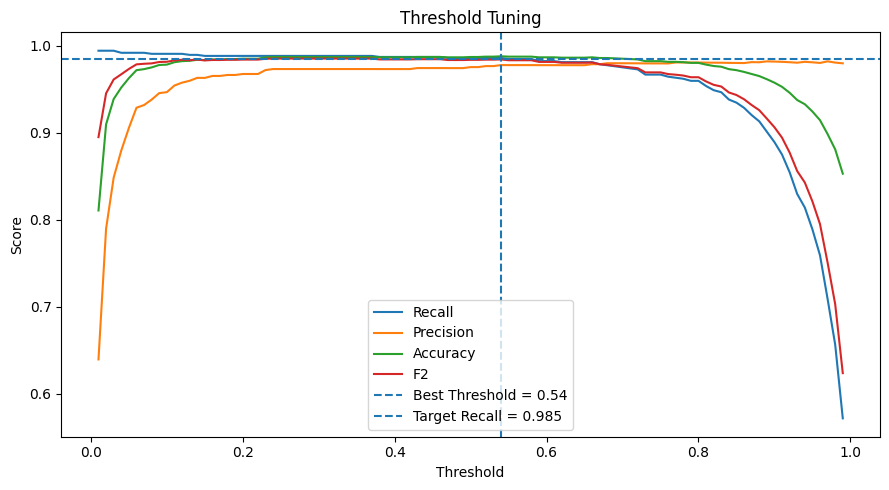

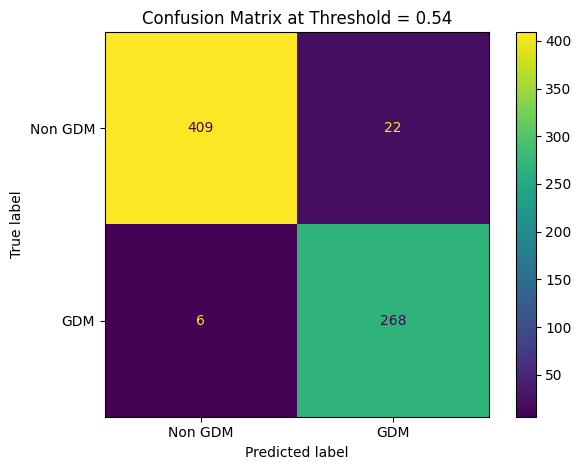

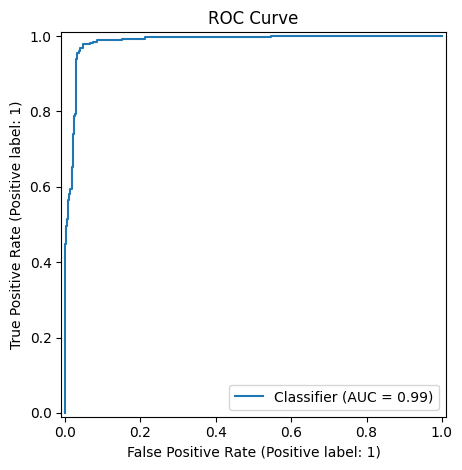

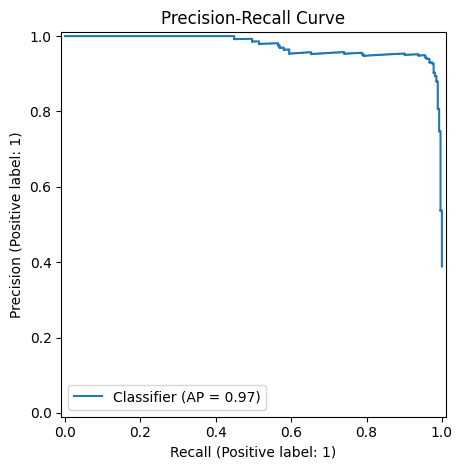

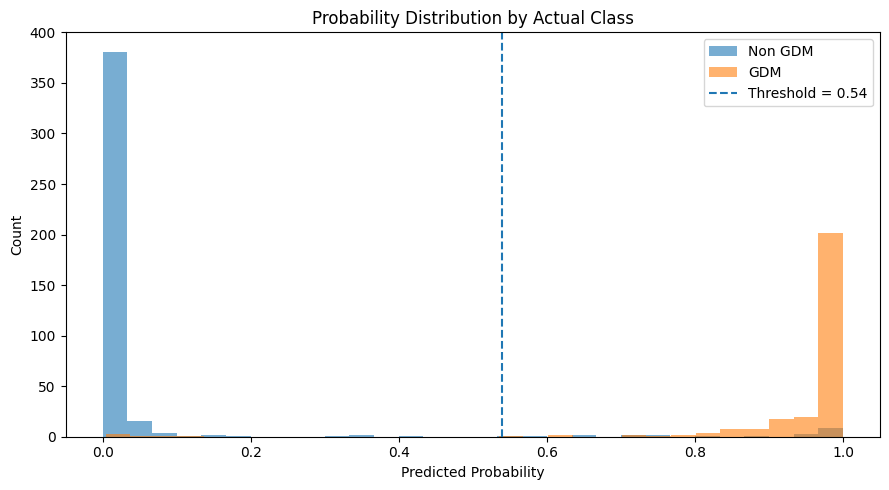

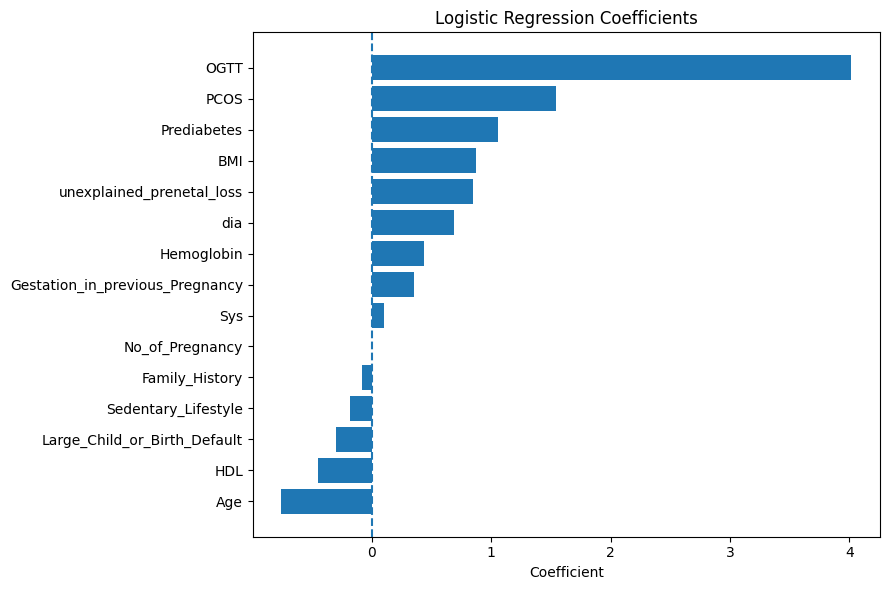

,Feature,Coefficient,Abs_Coefficient
0,Age,-0.758791,0.758791
4,HDL,-0.451731,0.451731
7,Large_Child_or_Birth_Default,-0.301240,0.301240
13,Sedentary_Lifestyle,-0.179520,0.179520
5,Family_History,-0.079745,0.079745
1,No_of_Pregnancy,0.000716,0.000716
9,Sys,0.100698,0.100698
2,Gestation_in_previous_Pregnancy,0.355761,0.355761
12,Hemoglobin,0.434324,0.434324
10,dia,0.689333,0.689333


In [ ]:
plot_all_model_diagnostics(
    tuned_object=logistic_tuned,
    X=x_test,
    y=y_test
)

coef_df = plot_logistic_coefficients(
    tuned_object=logistic_tuned,
    top_n=None
)
coef_df

### SVM -- Linear

#### tuning model

In [96]:
svm_linear_param_grid = {
    "kernel": ["linear"],
    "C": [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    "class_weight": ["balanced", None]
}

svm_linear_tuned = tune_model_with_threshold(
    X_train=x_train,
    y_train=y_train,
    model_builder=lambda **params: SVC(
        probability=True,
        random_state=1,
        **params
    ),
    param_grid=svm_linear_param_grid,
    scaler_class=StandardScaler,
    target_recall=0.985,
    selection_metric="accuracy",
    cv_splits=5,
    random_state=1,
    verbose=True
)

Done 1/18 | Recall=0.9857 | Accuracy=0.9749 | Threshold=0.2
Done 2/18 | Recall=0.9857 | Accuracy=0.9521 | Threshold=0.13
Done 3/18 | Recall=0.9905 | Accuracy=0.9880 | Threshold=0.55
Done 4/18 | Recall=0.9905 | Accuracy=0.9856 | Threshold=0.3
Done 5/18 | Recall=0.9881 | Accuracy=0.9880 | Threshold=0.66
Done 6/18 | Recall=0.9916 | Accuracy=0.9876 | Threshold=0.46
Done 7/18 | Recall=0.9916 | Accuracy=0.9884 | Threshold=0.56
Done 8/18 | Recall=0.9916 | Accuracy=0.9884 | Threshold=0.48
Done 9/18 | Recall=0.9893 | Accuracy=0.9884 | Threshold=0.7
Done 10/18 | Recall=0.9905 | Accuracy=0.9884 | Threshold=0.47
Done 11/18 | Recall=0.9881 | Accuracy=0.9884 | Threshold=0.68
Done 12/18 | Recall=0.9869 | Accuracy=0.9884 | Threshold=0.7
Done 13/18 | Recall=0.9893 | Accuracy=0.9888 | Threshold=0.58
Done 14/18 | Recall=0.9857 | Accuracy=0.9880 | Threshold=0.7
Done 15/18 | Recall=0.9893 | Accuracy=0.9888 | Threshold=0.59
Done 16/18 | Recall=0.9857 | Accuracy=0.9880 | Threshold=0.7
Done 17/18 | Recall=0.9

,param_id,C,class_weight,kernel,best_threshold,hit_target_recall,CV_TP,CV_TN,CV_FP,CV_FN,CV_accuracy,CV_recall,CV_precision,CV_specificity,CV_f1,CV_f2,CV_roc_auc,CV_pr_auc
16,params_17,10.0,balanced,linear,0.64,True,829,1649,19,9,0.988827,0.98926,0.977594,0.988609,0.983393,0.986905,0.992196,0.983938


#### Best Model

In [97]:
svm_linear_test_metrics, svm_linear_predictions_df = evaluate_tuned_model(
    tuned_object=svm_linear_tuned,
    X=x_test,
    y=y_test,
    dataset_name="SVM Linear Test"
)

svm_linear_predictions_df.head()

SVM Linear Test Metrics
----------------------------------------
dataset: SVM Linear Test
threshold: 0.6400
TP: 269
TN: 411
FP: 20
FN: 5
accuracy: 0.9645
recall: 0.9818
precision: 0.9308
specificity: 0.9536
f1: 0.9556
f2: 0.9711
roc_auc: 0.9821
pr_auc: 0.9677

Classification Report:
              precision    recall  f1-score   support

     Non GDM       0.99      0.95      0.97       431
         GDM       0.93      0.98      0.96       274

    accuracy                           0.96       705
   macro avg       0.96      0.97      0.96       705
weighted avg       0.97      0.96      0.96       705



,Age,No_of_Pregnancy,Gestation_in_previous_Pregnancy,BMI,HDL,Family_History,unexplained_prenetal_loss,Large_Child_or_Birth_Default,PCOS,Sys,dia,OGTT,Hemoglobin,Sedentary_Lifestyle,Prediabetes,Actual_GDM,GDM_Probability,Predicted_GDM
1366,26,1,0,21.400000,52.000000,0,0,0,0,114.548813,72,128.0,15.0,0,0,0,0.000959,0
753,38,3,1,24.919454,53.000000,0,1,0,0,122.411361,61,154.0,14.0,1,0,0,0.020769,0
2885,34,3,2,27.500000,27.655543,0,1,1,0,139.000000,81,174.0,16.9,0,1,1,0.969724,1
3252,36,1,0,44.700000,16.000000,1,0,1,0,140.000000,95,311.0,12.0,1,0,1,1.000000,1
601,32,2,1,26.045730,40.000000,1,1,0,0,122.763152,82,124.0,13.0,1,0,0,0.006681,0


#### Model Plots 

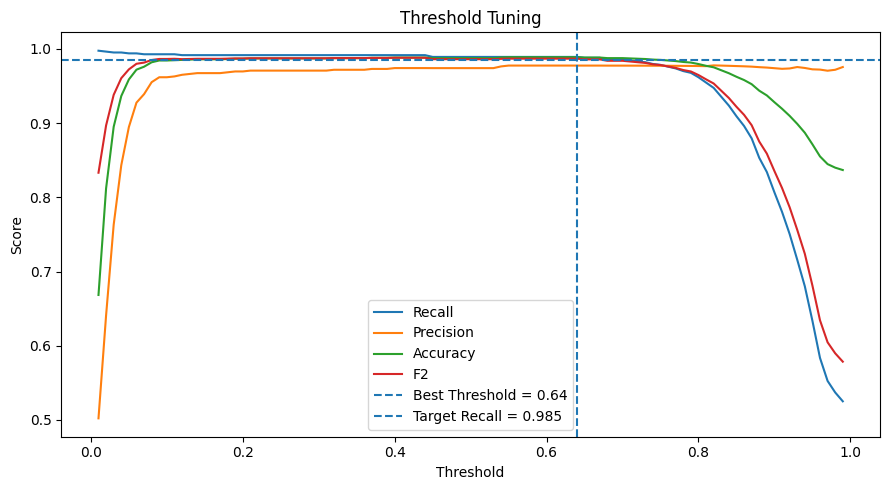

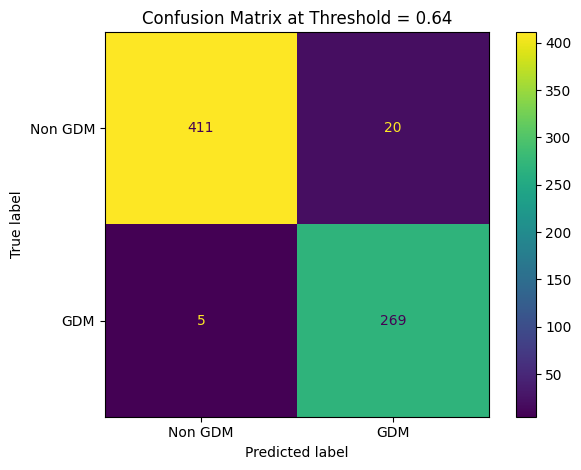

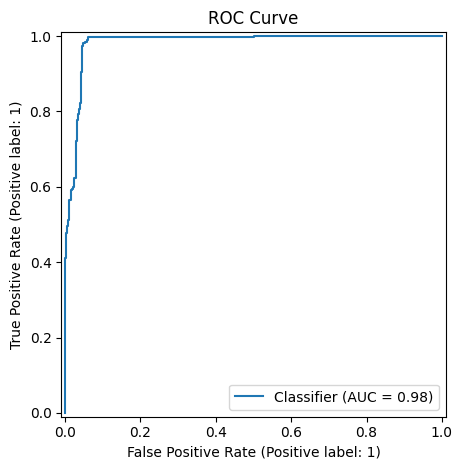

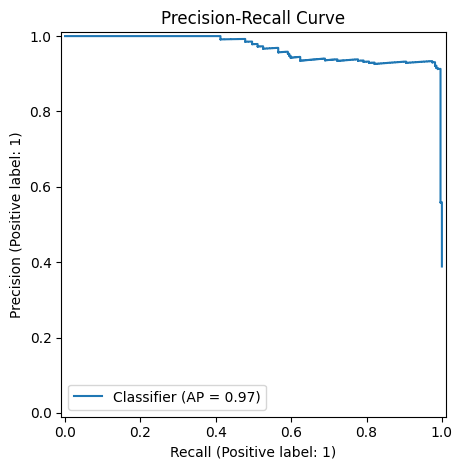

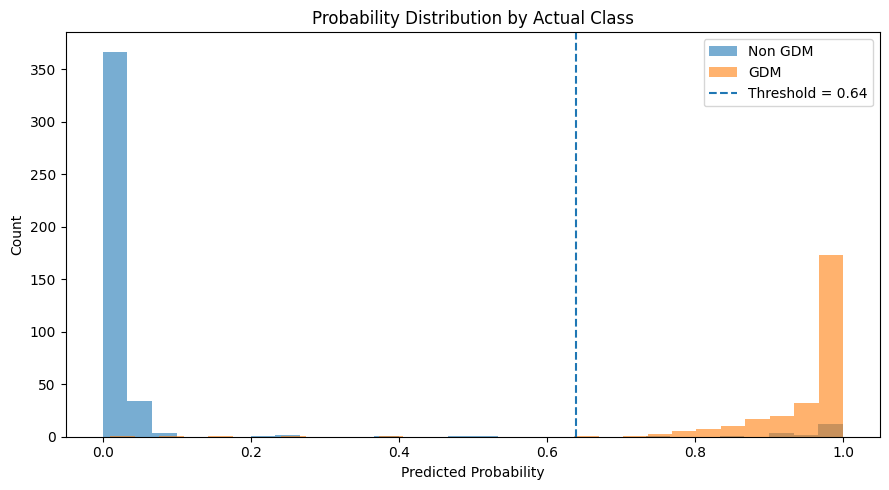

In [98]:
plot_all_model_diagnostics(
    tuned_object=svm_linear_tuned,
    X=x_test,
    y=y_test
)

### SVM Polynomial

#### tuning model

In [99]:
svm_poly_param_grid = {
    "kernel": ["poly"],
    "C": [0.01, 0.03, 0.1, 0.3, 1, 3],
    "degree": [2, 3, 4],
    "gamma": ["scale", "auto"],
    "coef0": [0, 0.5, 1],
    "class_weight": ["balanced", None]
}

svm_poly_tuned = tune_model_with_threshold(
    X_train=x_train,
    y_train=y_train,
    model_builder=lambda **params: SVC(
        probability=True,
        random_state=1,
        **params
    ),
    param_grid=svm_poly_param_grid,
    scaler_class=StandardScaler,
    target_recall=0.985,
    selection_metric="accuracy",
    cv_splits=5,
    random_state=1,
    verbose=True
)

Done 1/216 | Recall=0.9869 | Accuracy=0.8093 | Threshold=0.07
Done 2/216 | Recall=0.9869 | Accuracy=0.8093 | Threshold=0.07
Done 3/216 | Recall=0.9893 | Accuracy=0.9864 | Threshold=0.27
Done 4/216 | Recall=0.9893 | Accuracy=0.9864 | Threshold=0.27
Done 5/216 | Recall=0.9916 | Accuracy=0.9226 | Threshold=0.06
Done 6/216 | Recall=0.9916 | Accuracy=0.9226 | Threshold=0.06
Done 7/216 | Recall=0.9952 | Accuracy=0.9864 | Threshold=0.29
Done 8/216 | Recall=0.9952 | Accuracy=0.9864 | Threshold=0.29
Done 9/216 | Recall=0.9928 | Accuracy=0.9876 | Threshold=0.34
Done 10/216 | Recall=0.9928 | Accuracy=0.9876 | Threshold=0.34
Done 11/216 | Recall=0.9916 | Accuracy=0.9872 | Threshold=0.18
Done 12/216 | Recall=0.9916 | Accuracy=0.9872 | Threshold=0.18
Done 13/216 | Recall=0.9869 | Accuracy=0.9864 | Threshold=0.58
Done 14/216 | Recall=0.9869 | Accuracy=0.9864 | Threshold=0.58
Done 15/216 | Recall=0.9881 | Accuracy=0.9880 | Threshold=0.53
Done 16/216 | Recall=0.9881 | Accuracy=0.9880 | Threshold=0.53
D

,param_id,C,class_weight,coef0,degree,gamma,kernel,best_threshold,hit_target_recall,CV_TP,...,CV_FP,CV_FN,CV_accuracy,CV_recall,CV_precision,CV_specificity,CV_f1,CV_f2,CV_roc_auc,CV_pr_auc
210,params_211,3.0,None,1.0,2,scale,poly,0.36,True,828,...,14,10,0.990423,0.988067,0.983373,0.991607,0.985714,0.987124,0.995962,0.992206


#### Best Model

In [100]:
svm_poly_test_metrics, svm_poly_predictions_df = evaluate_tuned_model(
    tuned_object=svm_poly_tuned,
    X=x_test,
    y=y_test,
    dataset_name="SVM Polynomial Test"
)

svm_poly_predictions_df.head()

SVM Polynomial Test Metrics
----------------------------------------
dataset: SVM Polynomial Test
threshold: 0.3600
TP: 260
TN: 418
FP: 13
FN: 14
accuracy: 0.9617
recall: 0.9489
precision: 0.9524
specificity: 0.9698
f1: 0.9506
f2: 0.9496
roc_auc: 0.9749
pr_auc: 0.9556

Classification Report:
              precision    recall  f1-score   support

     Non GDM       0.97      0.97      0.97       431
         GDM       0.95      0.95      0.95       274

    accuracy                           0.96       705
   macro avg       0.96      0.96      0.96       705
weighted avg       0.96      0.96      0.96       705



,Age,No_of_Pregnancy,Gestation_in_previous_Pregnancy,BMI,HDL,Family_History,unexplained_prenetal_loss,Large_Child_or_Birth_Default,PCOS,Sys,dia,OGTT,Hemoglobin,Sedentary_Lifestyle,Prediabetes,Actual_GDM,GDM_Probability,Predicted_GDM
1366,26,1,0,21.400000,52.000000,0,0,0,0,114.548813,72,128.0,15.0,0,0,0,0.000062,0
753,38,3,1,24.919454,53.000000,0,1,0,0,122.411361,61,154.0,14.0,1,0,0,0.009939,0
2885,34,3,2,27.500000,27.655543,0,1,1,0,139.000000,81,174.0,16.9,0,1,1,0.995483,1
3252,36,1,0,44.700000,16.000000,1,0,1,0,140.000000,95,311.0,12.0,1,0,1,0.941040,1
601,32,2,1,26.045730,40.000000,1,1,0,0,122.763152,82,124.0,13.0,1,0,0,0.013699,0


#### Model Plots

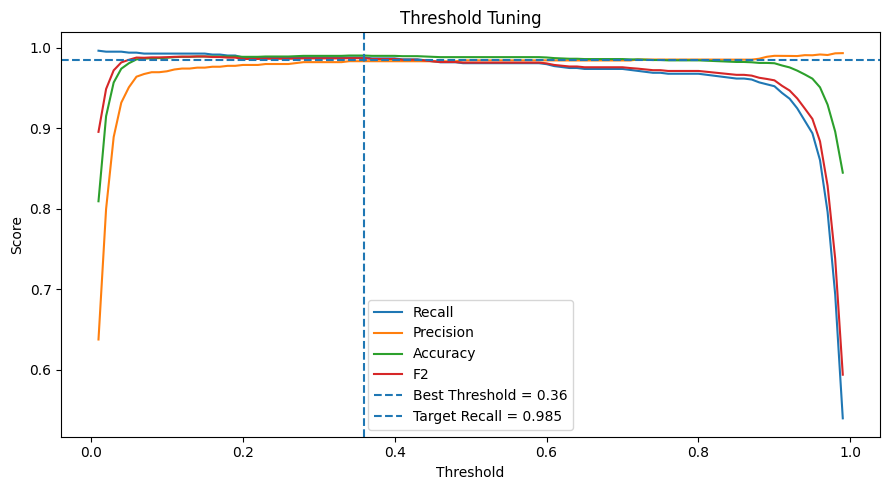

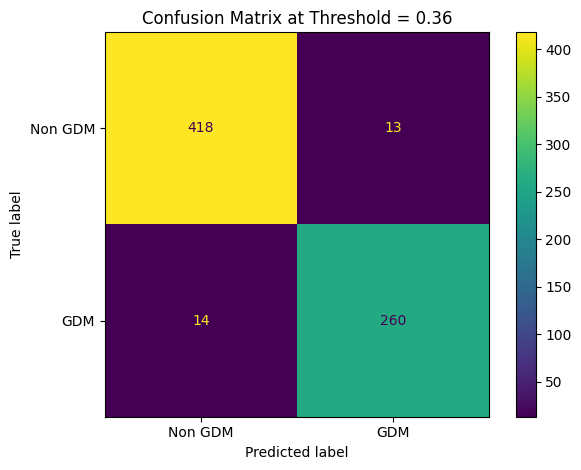

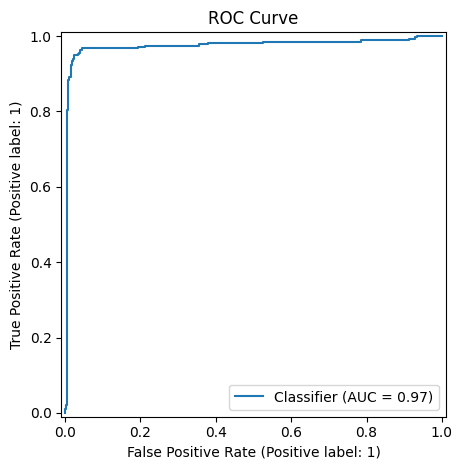

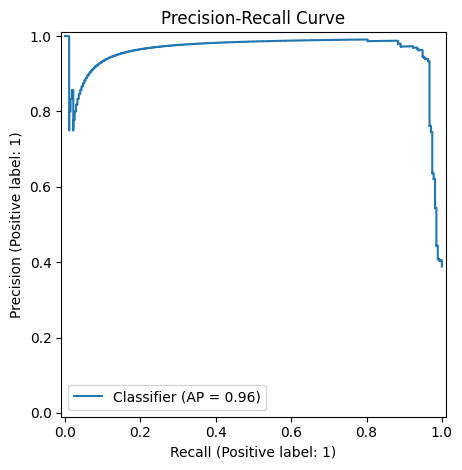

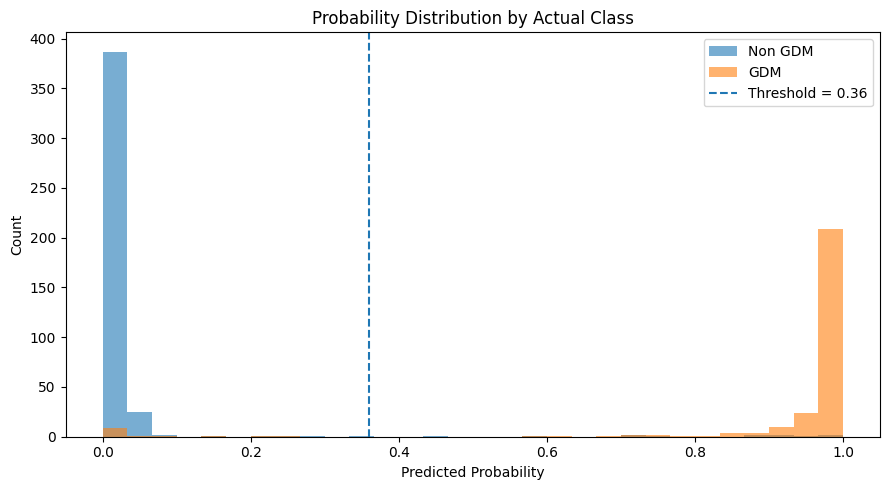

In [101]:
plot_all_model_diagnostics(
    tuned_object=svm_poly_tuned,
    X=x_test,
    y=y_test
)

### SVM RBF

#### tuning model


In [102]:
svm_rbf_param_grid = {
    "kernel": ["rbf"],
    "C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    "gamma": ["scale", "auto", 0.001, 0.003, 0.01, 0.03, 0.1],
    "class_weight": ["balanced", None]
}

svm_rbf_tuned = tune_model_with_threshold(
    X_train=x_train,
    y_train=y_train,
    model_builder=lambda **params: SVC(
        probability=True,
        random_state=1,
        **params
    ),
    param_grid=svm_rbf_param_grid,
    scaler_class=StandardScaler,
    target_recall=0.985,
    selection_metric="accuracy",
    cv_splits=5,
    random_state=1,
    verbose=True
)

Done 1/98 | Recall=0.9988 | Accuracy=0.9848 | Threshold=0.17
Done 2/98 | Recall=0.9988 | Accuracy=0.9848 | Threshold=0.17
Done 3/98 | Recall=1.0000 | Accuracy=0.4777 | Threshold=0.22
Done 4/98 | Recall=0.9916 | Accuracy=0.6987 | Threshold=0.02
Done 5/98 | Recall=0.9857 | Accuracy=0.8524 | Threshold=0.06
Done 6/98 | Recall=0.9916 | Accuracy=0.9800 | Threshold=0.2
Done 7/98 | Recall=0.9976 | Accuracy=0.9844 | Threshold=0.25
Done 8/98 | Recall=0.9976 | Accuracy=0.9844 | Threshold=0.21
Done 9/98 | Recall=0.9976 | Accuracy=0.9844 | Threshold=0.21
Done 10/98 | Recall=0.9905 | Accuracy=0.7474 | Threshold=0.06
Done 11/98 | Recall=0.9857 | Accuracy=0.7777 | Threshold=0.07
Done 12/98 | Recall=0.9869 | Accuracy=0.8982 | Threshold=0.08
Done 13/98 | Recall=0.9916 | Accuracy=0.9808 | Threshold=0.18
Done 14/98 | Recall=0.9976 | Accuracy=0.9844 | Threshold=0.36
Done 15/98 | Recall=0.9952 | Accuracy=0.9868 | Threshold=0.5
Done 16/98 | Recall=0.9952 | Accuracy=0.9868 | Threshold=0.5
Done 17/98 | Recall=

,param_id,C,class_weight,gamma,kernel,best_threshold,hit_target_recall,CV_TP,CV_TN,CV_FP,CV_FN,CV_accuracy,CV_recall,CV_precision,CV_specificity,CV_f1,CV_f2,CV_roc_auc,CV_pr_auc
69,params_70,1.0,None,0.1,rbf,0.48,True,826,1653,15,12,0.989226,0.98568,0.982164,0.991007,0.983919,0.984975,0.999554,0.999125


#### Best Model

In [103]:
svm_rbf_test_metrics, svm_rbf_predictions_df = evaluate_tuned_model(
    tuned_object=svm_rbf_tuned,
    X=x_test,
    y=y_test,
    dataset_name="SVM RBF Test"
)

svm_rbf_predictions_df.head()

SVM RBF Test Metrics
----------------------------------------
dataset: SVM RBF Test
threshold: 0.4800
TP: 268
TN: 418
FP: 13
FN: 6
accuracy: 0.9730
recall: 0.9781
precision: 0.9537
specificity: 0.9698
f1: 0.9658
f2: 0.9731
roc_auc: 0.9965
pr_auc: 0.9944

Classification Report:
              precision    recall  f1-score   support

     Non GDM       0.99      0.97      0.98       431
         GDM       0.95      0.98      0.97       274

    accuracy                           0.97       705
   macro avg       0.97      0.97      0.97       705
weighted avg       0.97      0.97      0.97       705



,Age,No_of_Pregnancy,Gestation_in_previous_Pregnancy,BMI,HDL,Family_History,unexplained_prenetal_loss,Large_Child_or_Birth_Default,PCOS,Sys,dia,OGTT,Hemoglobin,Sedentary_Lifestyle,Prediabetes,Actual_GDM,GDM_Probability,Predicted_GDM
1366,26,1,0,21.400000,52.000000,0,0,0,0,114.548813,72,128.0,15.0,0,0,0,0.000397,0
753,38,3,1,24.919454,53.000000,0,1,0,0,122.411361,61,154.0,14.0,1,0,0,0.002130,0
2885,34,3,2,27.500000,27.655543,0,1,1,0,139.000000,81,174.0,16.9,0,1,1,0.993928,1
3252,36,1,0,44.700000,16.000000,1,0,1,0,140.000000,95,311.0,12.0,1,0,1,0.483879,1
601,32,2,1,26.045730,40.000000,1,1,0,0,122.763152,82,124.0,13.0,1,0,0,0.000824,0


#### Model Plots

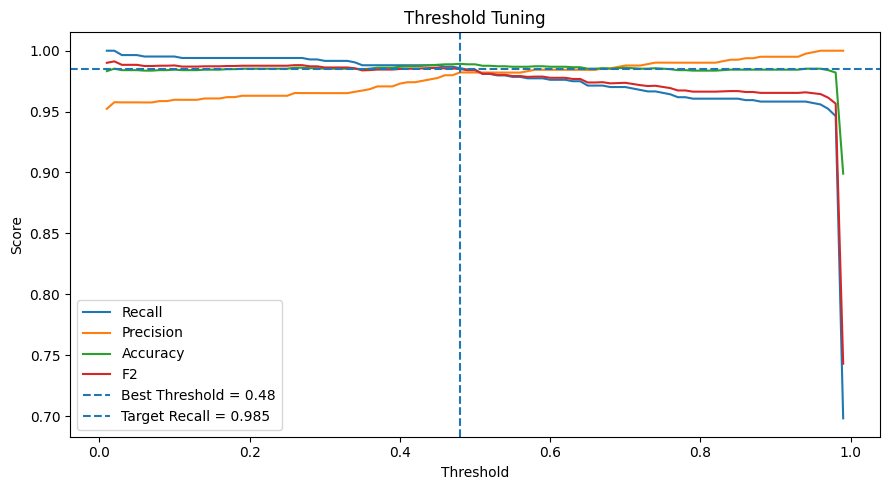

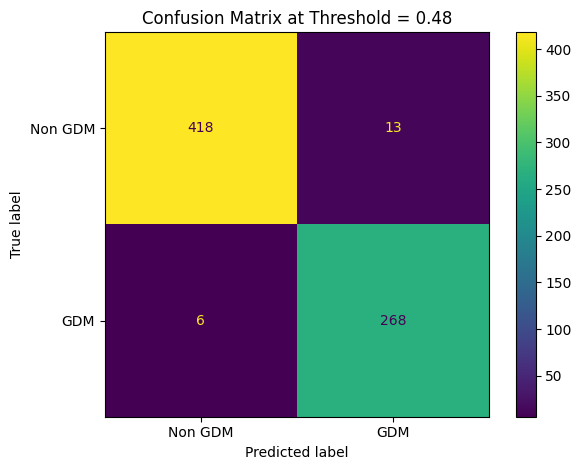

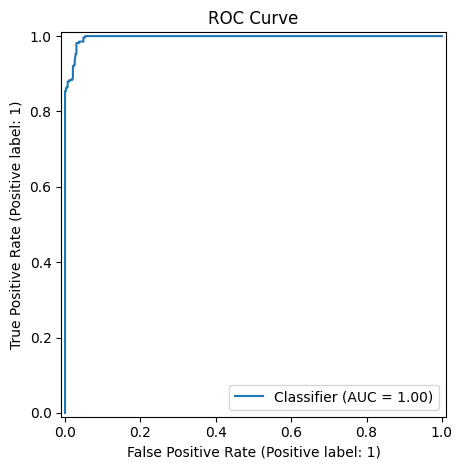

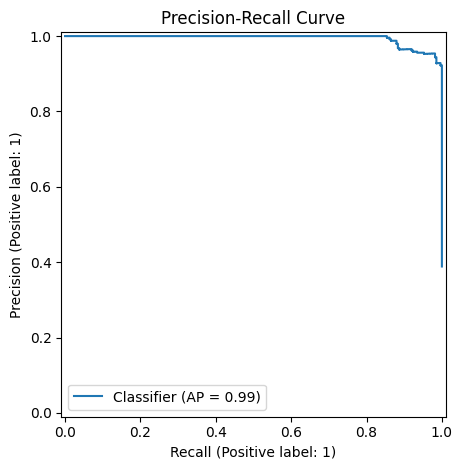

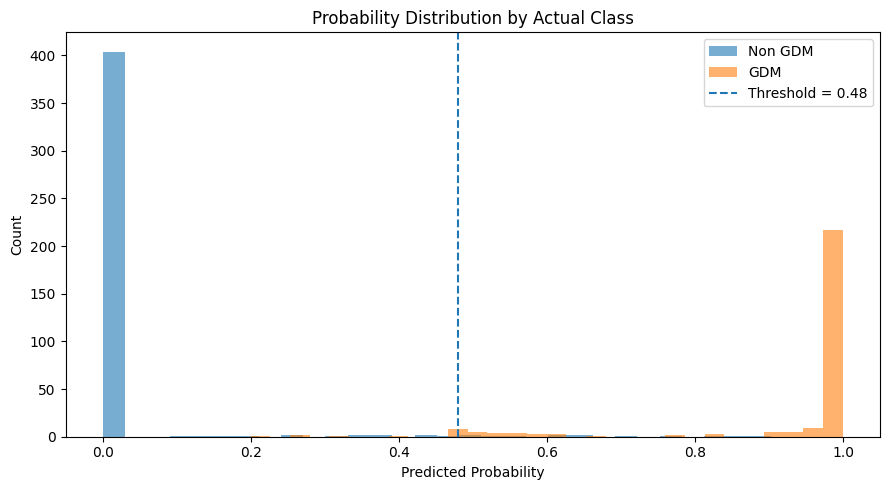

In [104]:
plot_all_model_diagnostics(
    tuned_object=svm_rbf_tuned,
    X=x_test,
    y=y_test
)

### Decision Tree

#### tuning model


In [108]:
from sklearn.tree import DecisionTreeClassifier

dt_param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3, 4, 5, 6, 7, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced", None],
    "ccp_alpha": [0.0, 0.001, 0.003]
}


def build_decision_tree(**params):
    params = params.copy()

    if params.get("max_depth") is not None and not pd.isna(params.get("max_depth")):
        params["max_depth"] = int(params["max_depth"])
    else:
        params["max_depth"] = None

    params["min_samples_split"] = int(params["min_samples_split"])
    params["min_samples_leaf"] = int(params["min_samples_leaf"])

    return DecisionTreeClassifier(
        random_state=1,
        **params
    )


dt_tuned = tune_model_with_threshold(
    X_train=x_train,
    y_train=y_train,
    model_builder=build_decision_tree,
    param_grid=dt_param_grid,
    scaler_class=None,
    target_recall=0.985,
    selection_metric="accuracy",
    cv_splits=5,
    random_state=1,
    verbose=True
)

Done 1/1296 | Recall=0.9928 | Accuracy=0.9860 | Threshold=0.64
Done 2/1296 | Recall=0.9928 | Accuracy=0.9860 | Threshold=0.64
Done 3/1296 | Recall=0.9928 | Accuracy=0.9860 | Threshold=0.64
Done 4/1296 | Recall=0.9928 | Accuracy=0.9856 | Threshold=0.64
Done 5/1296 | Recall=0.9928 | Accuracy=0.9856 | Threshold=0.64
Done 6/1296 | Recall=0.9928 | Accuracy=0.9856 | Threshold=0.64
Done 7/1296 | Recall=0.9952 | Accuracy=0.9852 | Threshold=0.44
Done 8/1296 | Recall=0.9952 | Accuracy=0.9852 | Threshold=0.44
Done 9/1296 | Recall=0.9952 | Accuracy=0.9852 | Threshold=0.44
Done 10/1296 | Recall=0.9905 | Accuracy=0.9864 | Threshold=0.49
Done 11/1296 | Recall=0.9905 | Accuracy=0.9864 | Threshold=0.49
Done 12/1296 | Recall=0.9928 | Accuracy=0.9868 | Threshold=0.39
Done 13/1296 | Recall=0.9928 | Accuracy=0.9860 | Threshold=0.49
Done 14/1296 | Recall=0.9928 | Accuracy=0.9860 | Threshold=0.49
Done 15/1296 | Recall=0.9952 | Accuracy=0.9864 | Threshold=0.39
Done 16/1296 | Recall=0.9952 | Accuracy=0.9860 | 

,param_id,ccp_alpha,class_weight,criterion,max_depth,min_samples_leaf,min_samples_split,best_threshold,hit_target_recall,CV_TP,...,CV_FP,CV_FN,CV_accuracy,CV_recall,CV_precision,CV_specificity,CV_f1,CV_f2,CV_roc_auc,CV_pr_auc
39,params_40,0.0,balanced,gini,7.0,2,2,0.49,True,832,...,22,6,0.988827,0.99284,0.974239,0.986811,0.983452,0.989063,0.98918,0.965051


#### Best Model

In [109]:
dt_test_metrics, dt_predictions_df = evaluate_tuned_model(
    tuned_object=dt_tuned,
    X=x_test,
    y=y_test,
    dataset_name="Decision Tree Test"
)

dt_predictions_df.head()

Decision Tree Test Metrics
----------------------------------------
dataset: Decision Tree Test
threshold: 0.4900
TP: 268
TN: 414
FP: 17
FN: 6
accuracy: 0.9674
recall: 0.9781
precision: 0.9404
specificity: 0.9606
f1: 0.9589
f2: 0.9703
roc_auc: 0.9672
pr_auc: 0.9228

Classification Report:
              precision    recall  f1-score   support

     Non GDM       0.99      0.96      0.97       431
         GDM       0.94      0.98      0.96       274

    accuracy                           0.97       705
   macro avg       0.96      0.97      0.97       705
weighted avg       0.97      0.97      0.97       705



,Age,No_of_Pregnancy,Gestation_in_previous_Pregnancy,BMI,HDL,Family_History,unexplained_prenetal_loss,Large_Child_or_Birth_Default,PCOS,Sys,dia,OGTT,Hemoglobin,Sedentary_Lifestyle,Prediabetes,Actual_GDM,GDM_Probability,Predicted_GDM
1366,26,1,0,21.400000,52.000000,0,0,0,0,114.548813,72,128.0,15.0,0,0,0,0.000000,0
753,38,3,1,24.919454,53.000000,0,1,0,0,122.411361,61,154.0,14.0,1,0,0,0.000000,0
2885,34,3,2,27.500000,27.655543,0,1,1,0,139.000000,81,174.0,16.9,0,1,1,0.999338,1
3252,36,1,0,44.700000,16.000000,1,0,1,0,140.000000,95,311.0,12.0,1,0,1,1.000000,1
601,32,2,1,26.045730,40.000000,1,1,0,0,122.763152,82,124.0,13.0,1,0,0,0.000000,0


#### Model Plots

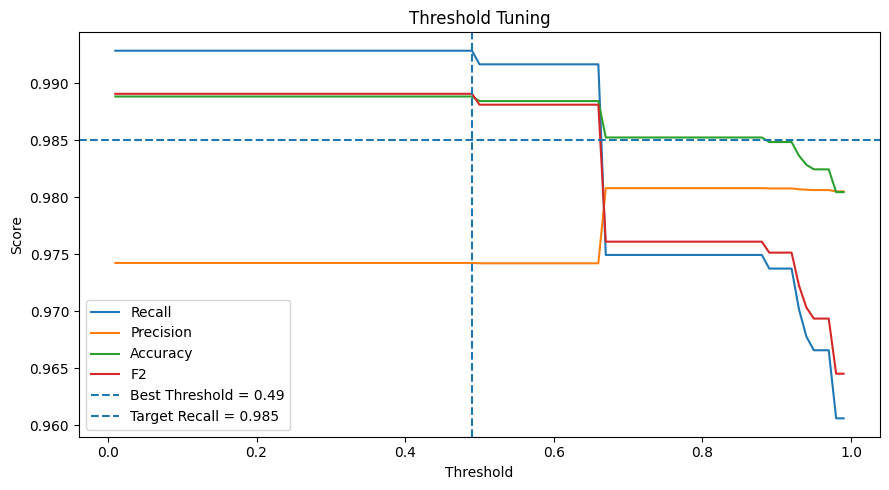

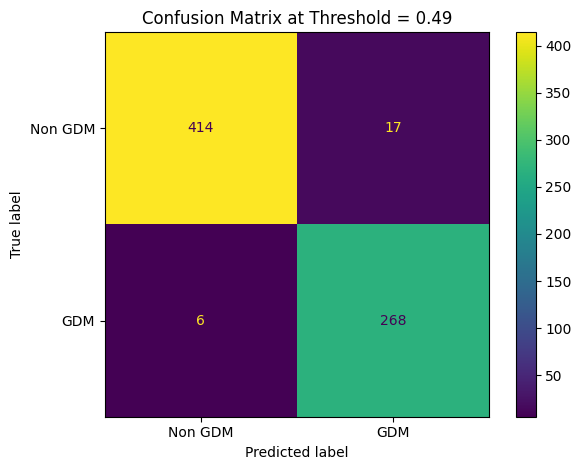

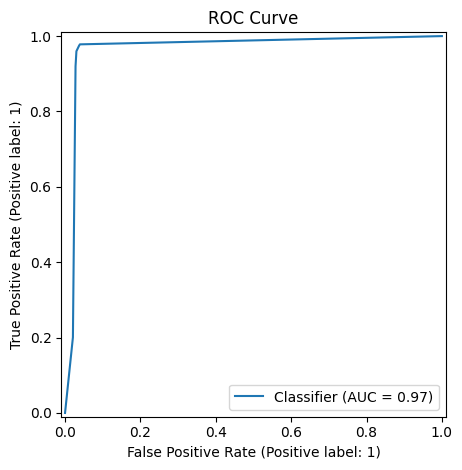

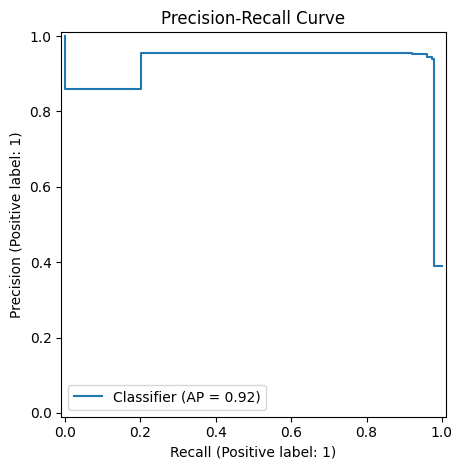

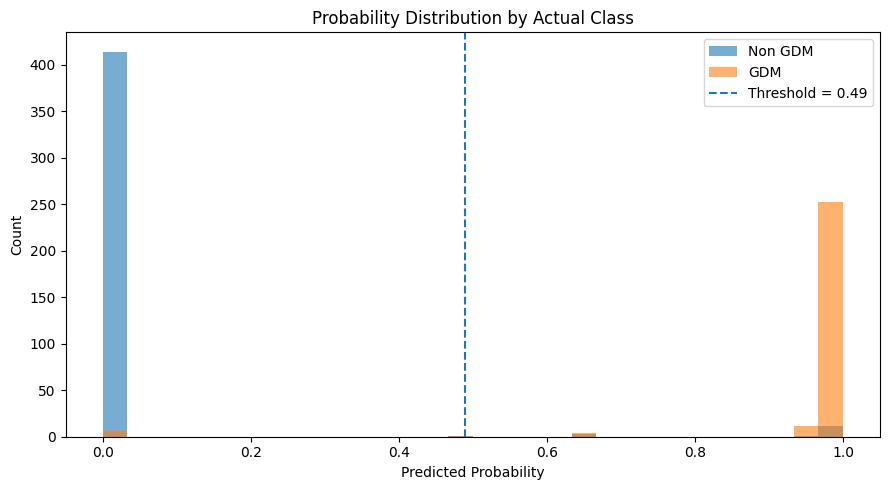

In [110]:
plot_all_model_diagnostics(
    tuned_object=dt_tuned,
    X=x_test,
    y=y_test
)

### Random Forest

#### tuning model


In [112]:
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    "n_estimators": [100, 200],
    "criterion": ["gini", "entropy"],
    "max_depth": [4, 5, 6, 8],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", "balanced_subsample"]
}


def build_random_forest(**params):
    params = params.copy()

    if params.get("max_depth") is not None and not pd.isna(params.get("max_depth")):
        params["max_depth"] = int(params["max_depth"])
    else:
        params["max_depth"] = None

    params["n_estimators"] = int(params["n_estimators"])
    params["min_samples_split"] = int(params["min_samples_split"])
    params["min_samples_leaf"] = int(params["min_samples_leaf"])

    return RandomForestClassifier(
        random_state=1,
        n_jobs=-1,
        **params
    )


rf_tuned = tune_model_with_threshold(
    X_train=x_train,
    y_train=y_train,
    model_builder=build_random_forest,
    param_grid=rf_param_grid,
    scaler_class=None,
    target_recall=0.985,
    selection_metric="accuracy",
    cv_splits=5,
    random_state=1,
    verbose=True
)

Done 1/864 | Recall=0.9928 | Accuracy=0.9856 | Threshold=0.57
Done 2/864 | Recall=0.9928 | Accuracy=0.9864 | Threshold=0.55
Done 3/864 | Recall=0.9940 | Accuracy=0.9860 | Threshold=0.54
Done 4/864 | Recall=0.9905 | Accuracy=0.9856 | Threshold=0.58
Done 5/864 | Recall=0.9952 | Accuracy=0.9860 | Threshold=0.54
Done 6/864 | Recall=0.9905 | Accuracy=0.9860 | Threshold=0.59
Done 7/864 | Recall=0.9976 | Accuracy=0.9860 | Threshold=0.46
Done 8/864 | Recall=0.9940 | Accuracy=0.9860 | Threshold=0.53
Done 9/864 | Recall=0.9916 | Accuracy=0.9860 | Threshold=0.6
Done 10/864 | Recall=0.9916 | Accuracy=0.9856 | Threshold=0.57
Done 11/864 | Recall=0.9952 | Accuracy=0.9860 | Threshold=0.54
Done 12/864 | Recall=0.9893 | Accuracy=0.9856 | Threshold=0.6
Done 13/864 | Recall=0.9916 | Accuracy=0.9864 | Threshold=0.62
Done 14/864 | Recall=0.9976 | Accuracy=0.9860 | Threshold=0.5
Done 15/864 | Recall=0.9916 | Accuracy=0.9864 | Threshold=0.62
Done 16/864 | Recall=0.9976 | Accuracy=0.9860 | Threshold=0.5
Done 

,param_id,class_weight,criterion,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,best_threshold,hit_target_recall,...,CV_FP,CV_FN,CV_accuracy,CV_recall,CV_precision,CV_specificity,CV_f1,CV_f2,CV_roc_auc,CV_pr_auc
330,params_331,balanced,entropy,6,sqrt,2,2,100,0.62,True,...,19,9,0.988827,0.98926,0.977594,0.988609,0.983393,0.986905,0.999576,0.999167


#### Best Model

In [113]:
rf_test_metrics, rf_predictions_df = evaluate_tuned_model(
    tuned_object=rf_tuned,
    X=x_test,
    y=y_test,
    dataset_name="Random Forest Test"
)

rf_predictions_df.head()

Random Forest Test Metrics
----------------------------------------
dataset: Random Forest Test
threshold: 0.6200
TP: 264
TN: 414
FP: 17
FN: 10
accuracy: 0.9617
recall: 0.9635
precision: 0.9395
specificity: 0.9606
f1: 0.9514
f2: 0.9586
roc_auc: 0.9971
pr_auc: 0.9956

Classification Report:
              precision    recall  f1-score   support

     Non GDM       0.98      0.96      0.97       431
         GDM       0.94      0.96      0.95       274

    accuracy                           0.96       705
   macro avg       0.96      0.96      0.96       705
weighted avg       0.96      0.96      0.96       705



,Age,No_of_Pregnancy,Gestation_in_previous_Pregnancy,BMI,HDL,Family_History,unexplained_prenetal_loss,Large_Child_or_Birth_Default,PCOS,Sys,dia,OGTT,Hemoglobin,Sedentary_Lifestyle,Prediabetes,Actual_GDM,GDM_Probability,Predicted_GDM
1366,26,1,0,21.400000,52.000000,0,0,0,0,114.548813,72,128.0,15.0,0,0,0,0.001959,0
753,38,3,1,24.919454,53.000000,0,1,0,0,122.411361,61,154.0,14.0,1,0,0,0.002993,0
2885,34,3,2,27.500000,27.655543,0,1,1,0,139.000000,81,174.0,16.9,0,1,1,0.999051,1
3252,36,1,0,44.700000,16.000000,1,0,1,0,140.000000,95,311.0,12.0,1,0,1,0.614650,0
601,32,2,1,26.045730,40.000000,1,1,0,0,122.763152,82,124.0,13.0,1,0,0,0.006344,0


#### Model Plots

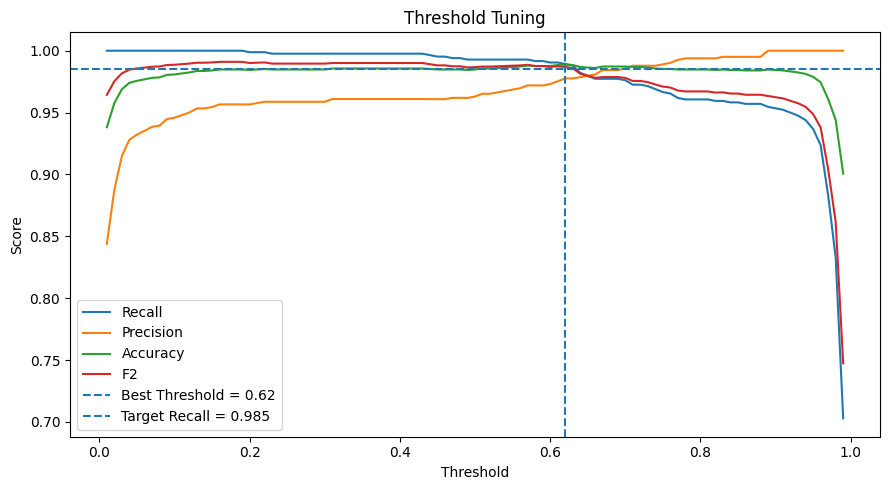

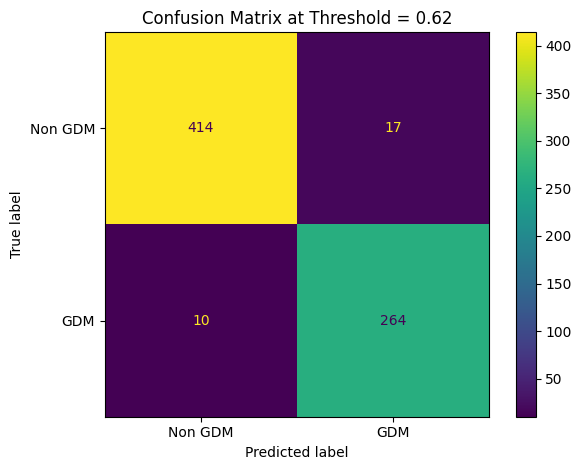

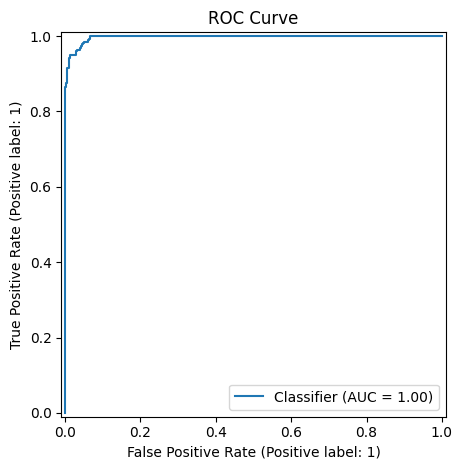

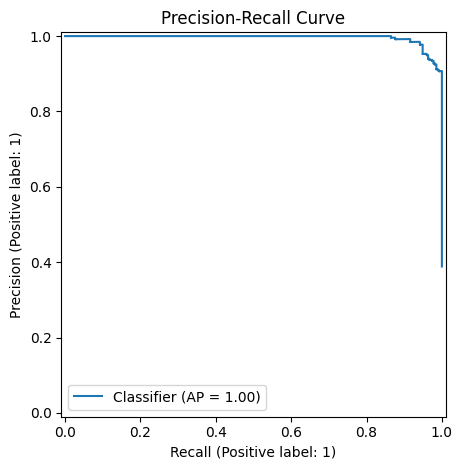

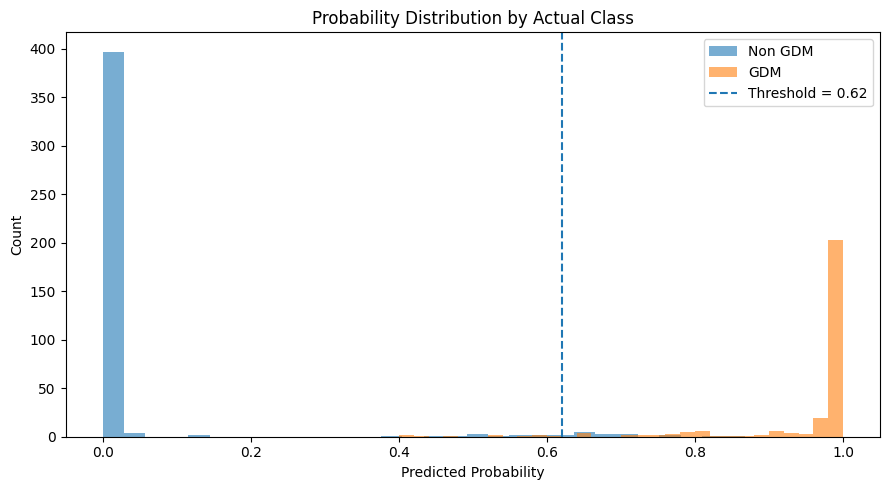

In [114]:
plot_all_model_diagnostics(
    tuned_object=rf_tuned,
    X=x_test,
    y=y_test
)

# Comparison

In [115]:
all_test_metrics = pd.DataFrame([
    logistic_test_metrics,
    svm_linear_test_metrics,
    svm_poly_test_metrics,
    svm_rbf_test_metrics,
    dt_test_metrics,
    rf_test_metrics
])

all_test_metrics = all_test_metrics.sort_values(
    by=["recall", "accuracy", "precision", "f2"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

all_test_metrics

,dataset,threshold,TP,TN,FP,FN,accuracy,recall,precision,specificity,f1,f2,roc_auc,pr_auc
0,SVM Linear Test,0.64,269,411,20,5,0.964539,0.981752,0.930796,0.953596,0.955595,0.971119,0.982107,0.967668
1,SVM RBF Test,0.48,268,418,13,6,0.973050,0.978102,0.953737,0.969838,0.965766,0.973130,0.996469,0.994387
2,Decision Tree Test,0.49,268,414,17,6,0.967376,0.978102,0.940351,0.960557,0.958855,0.970311,0.967213,0.922770
3,Test,0.54,268,409,22,6,0.960284,0.978102,0.924138,0.948956,0.950355,0.966811,0.985139,0.974524
4,Random Forest Test,0.62,264,414,17,10,0.961702,0.963504,0.939502,0.960557,0.951351,0.958606,0.997104,0.995580
5,SVM Polynomial Test,0.36,260,418,13,14,0.961702,0.948905,0.952381,0.969838,0.950640,0.949598,0.974859,0.955588


### Comparison plot

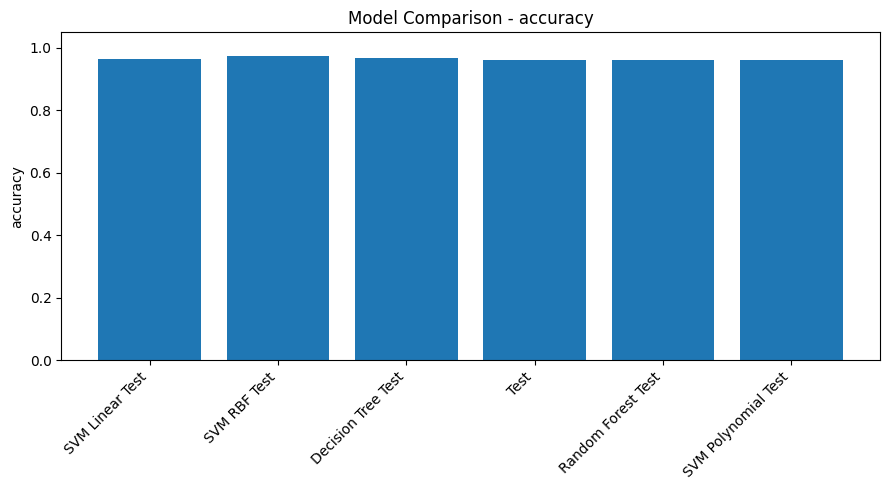

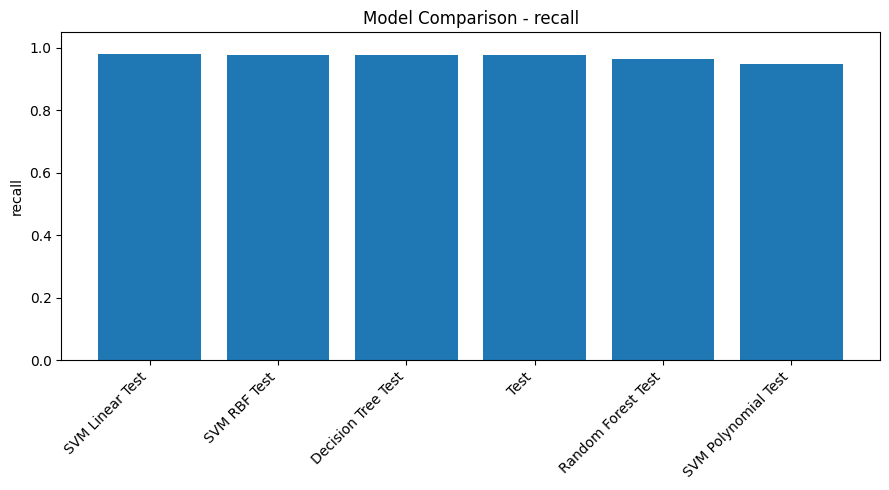

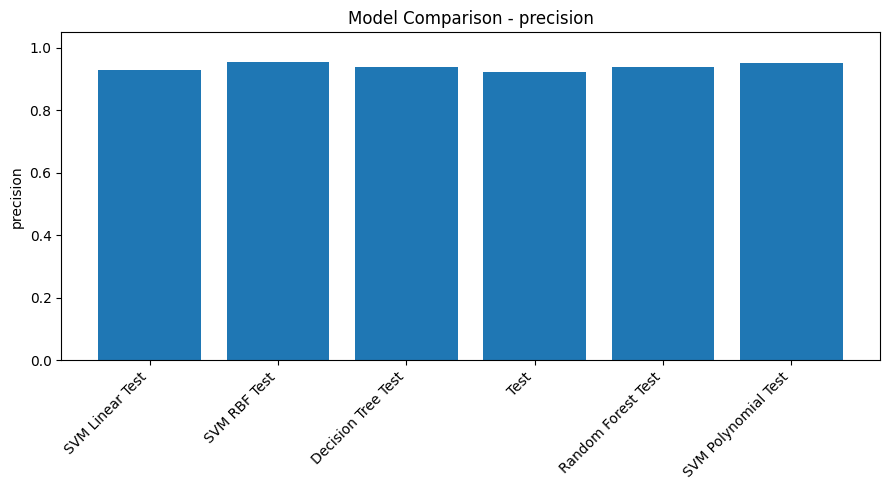

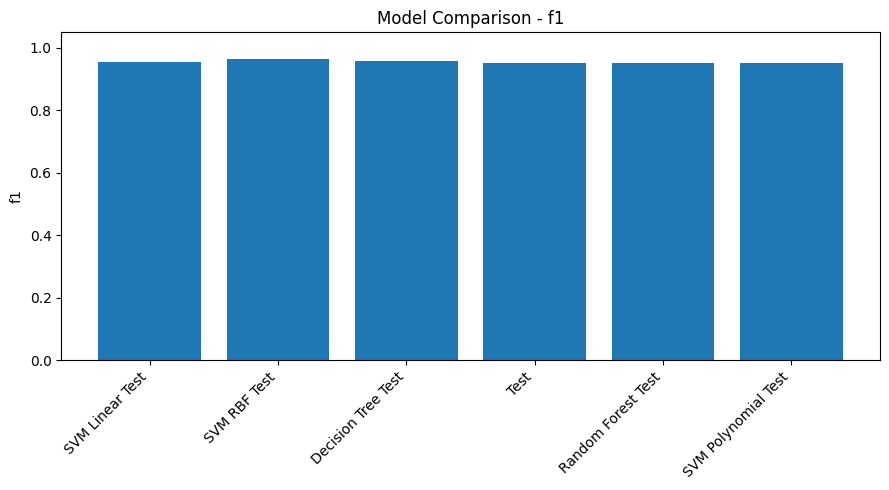

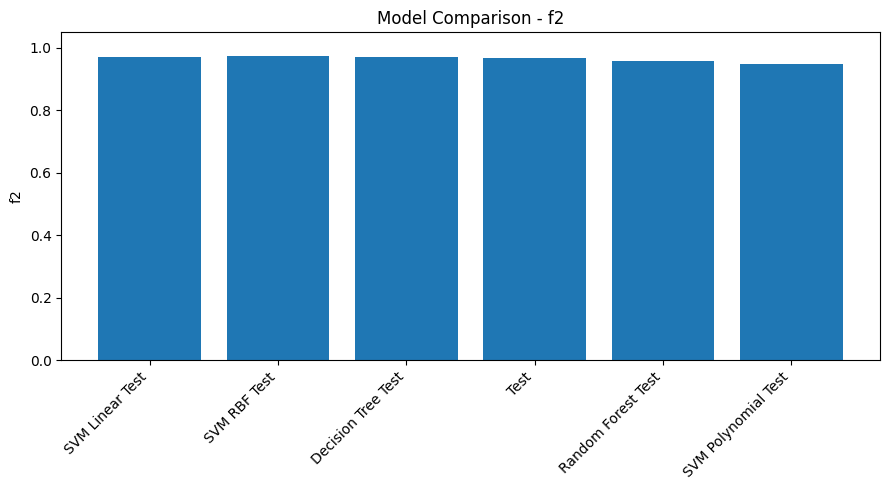

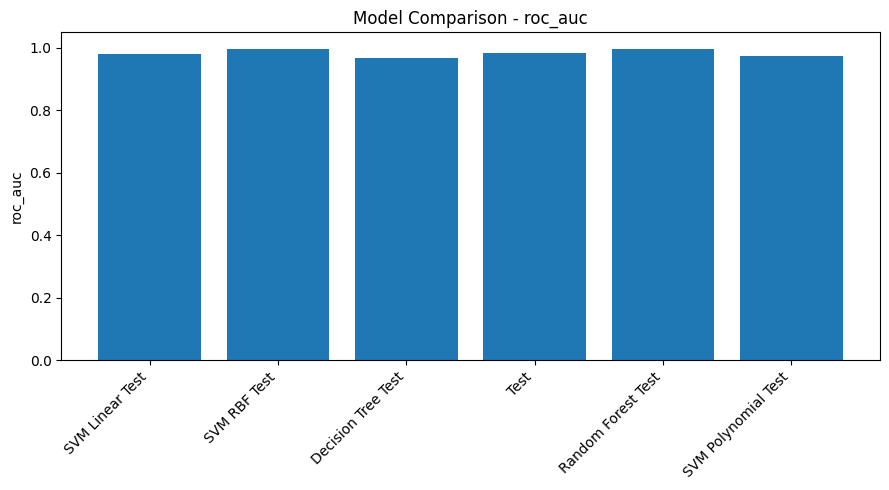

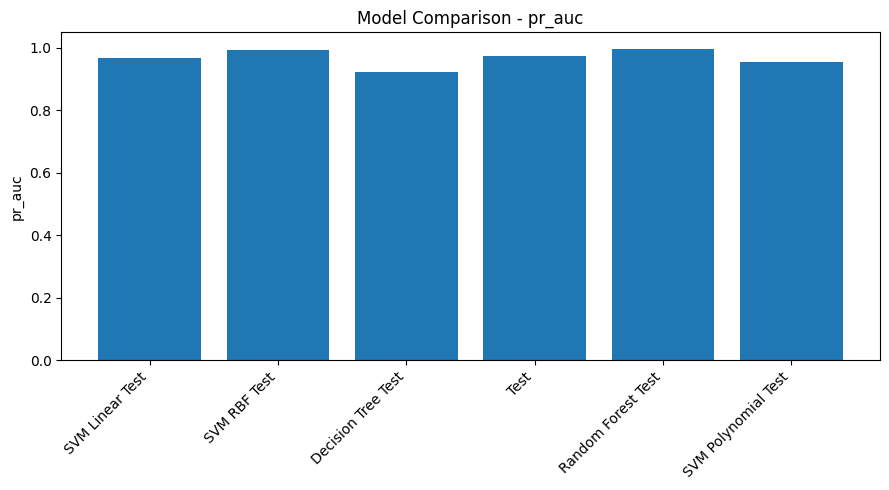

In [116]:
def plot_model_comparison(metrics_df):
    plot_df = metrics_df.copy()

    metrics_to_plot = ["accuracy", "recall", "precision", "f1", "f2", "roc_auc", "pr_auc"]

    for metric in metrics_to_plot:
        plt.figure(figsize=(9, 5))
        plt.bar(plot_df["dataset"], plot_df[metric])
        plt.ylim(0, 1.05)
        plt.xticks(rotation=45, ha="right")
        plt.ylabel(metric)
        plt.title(f"Model Comparison - {metric}")
        plt.tight_layout()
        plt.show()


plot_model_comparison(all_test_metrics)

# Save Models

In [117]:
import joblib
import os
from datetime import datetime

os.makedirs("saved_models", exist_ok=True)

all_tuned_models = {
    "logistic_regression": logistic_tuned,
    "svm_linear": svm_linear_tuned,
    "svm_poly": svm_poly_tuned,
    "svm_rbf": svm_rbf_tuned,
    "decision_tree": dt_tuned,
    "random_forest": rf_tuned
}

models_artifact = {
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "target_recall": 0.985,
    "models": {}
}

for model_name, tuned_obj in all_tuned_models.items():
    artifact = {
        "model_name": model_name,
        "model": tuned_obj["model"],
        "threshold": tuned_obj["threshold"],
        "best_params": tuned_obj["best_params"],
        "target_recall": tuned_obj["target_recall"],
        "selection_metric": tuned_obj["selection_metric"],
        "feature_names": tuned_obj["feature_names"]
    }

    file_path = f"saved_models/{model_name}_artifact.pkl"
    joblib.dump(artifact, file_path)

    models_artifact["models"][model_name] = file_path

    print(f"Saved {model_name} -> {file_path}")

joblib.dump(models_artifact, "saved_models/all_models_index.pkl")

print("\nSaved all models index -> saved_models/all_models_index.pkl")

Saved logistic_regression -> saved_models/logistic_regression_artifact.pkl
Saved svm_linear -> saved_models/svm_linear_artifact.pkl
Saved svm_poly -> saved_models/svm_poly_artifact.pkl
Saved svm_rbf -> saved_models/svm_rbf_artifact.pkl
Saved decision_tree -> saved_models/decision_tree_artifact.pkl
Saved random_forest -> saved_models/random_forest_artifact.pkl

Saved all models index -> saved_models/all_models_index.pkl


In [83]:
import joblib
import pandas as pd
import numpy as np

def load_all_models(index_path="saved_models/all_models_index.pkl"):
    index = joblib.load(index_path)

    loaded_models = {}

    for model_name, path in index["models"].items():
        loaded_models[model_name] = joblib.load(path)

    return loaded_models


def predict_all_saved_models(loaded_models, X):
    results = {}

    for model_name, artifact in loaded_models.items():
        model = artifact["model"]
        threshold = artifact["threshold"]
        feature_names = artifact["feature_names"]

        X_input = X.copy()

        if feature_names is not None:
            X_input = X_input[feature_names]

        probabilities = model.predict_proba(X_input)[:, 1]
        predictions = (probabilities >= threshold).astype(int)

        result_df = X_input.copy()
        result_df[f"{model_name}_GDM_Probability"] = probabilities
        result_df[f"{model_name}_Predicted_GDM"] = predictions

        results[model_name] = result_df

    return results

In [84]:
loaded_models = load_all_models("saved_models/all_models_index.pkl")

all_predictions = predict_all_saved_models(
    loaded_models=loaded_models,
    X=x_test
)

all_predictions["logistic_regression"].head()

,Age,No_of_Pregnancy,Gestation_in_previous_Pregnancy,BMI,HDL,Family_History,unexplained_prenetal_loss,Large_Child_or_Birth_Default,PCOS,Sys,dia,OGTT,Hemoglobin,Sedentary_Lifestyle,Prediabetes,logistic_regression_GDM_Probability,logistic_regression_Predicted_GDM
1366,26,1,0,21.400000,52.000000,0,0,0,0,114.548813,72,128.0,15.0,0,0,0.000260,0
753,38,3,1,24.919454,53.000000,0,1,0,0,122.411361,61,154.0,14.0,1,0,0.007526,0
2885,34,3,2,27.500000,27.655543,0,1,1,0,139.000000,81,174.0,16.9,0,1,0.991058,1
3252,36,1,0,44.700000,16.000000,1,0,1,0,140.000000,95,311.0,12.0,1,0,1.000000,1
601,32,2,1,26.045730,40.000000,1,1,0,0,122.763152,82,124.0,13.0,1,0,0.003209,0


In [85]:
all_predictions["random_forest"].head()

,Age,No_of_Pregnancy,Gestation_in_previous_Pregnancy,BMI,HDL,Family_History,unexplained_prenetal_loss,Large_Child_or_Birth_Default,PCOS,Sys,dia,OGTT,Hemoglobin,Sedentary_Lifestyle,Prediabetes,random_forest_GDM_Probability,random_forest_Predicted_GDM
1366,26,1,0,21.400000,52.000000,0,0,0,0,114.548813,72,128.0,15.0,0,0,0.001959,0
753,38,3,1,24.919454,53.000000,0,1,0,0,122.411361,61,154.0,14.0,1,0,0.002993,0
2885,34,3,2,27.500000,27.655543,0,1,1,0,139.000000,81,174.0,16.9,0,1,0.999051,1
3252,36,1,0,44.700000,16.000000,1,0,1,0,140.000000,95,311.0,12.0,1,0,0.614650,0
601,32,2,1,26.045730,40.000000,1,1,0,0,122.763152,82,124.0,13.0,1,0,0.006344,0


#### API request

In [211]:
'''
import requests

url = "http://127.0.0.1:8000/predict"

data = {
    "Age": 30,
    "No_of_Pregnancy": 2,
    "Gestation_in_previous_Pregnancy": 1,
    "BMI": 27.5,
    "HDL": 45,
    "Family_History": 1,
    "unexplained_prenetal_loss": 0,
    "Large_Child_or_Birth_Default": 0,
    "PCOS": 1,
    "Sys": 120,
    "dia": 80,
    "OGTT": 140,
    "Hemoglobin": 11.8,
    "Sedentary_Lifestyle": 1,
    "Prediabetes": 0
}

response = requests.post(url, json=data)

print(response.status_code)
print(response.json())
'''

'\nimport requests\n\nurl = "http://127.0.0.1:8000/predict"\n\ndata = {\n    "Age": 30,\n    "No_of_Pregnancy": 2,\n    "Gestation_in_previous_Pregnancy": 1,\n    "BMI": 27.5,\n    "HDL": 45,\n    "Family_History": 1,\n    "unexplained_prenetal_loss": 0,\n    "Large_Child_or_Birth_Default": 0,\n    "PCOS": 1,\n    "Sys": 120,\n    "dia": 80,\n    "OGTT": 140,\n    "Hemoglobin": 11.8,\n    "Sedentary_Lifestyle": 1,\n    "Prediabetes": 0\n}\n\nresponse = requests.post(url, json=data)\n\nprint(response.status_code)\nprint(response.json())\n'

In [88]:
loaded_models = load_all_models("saved_models/all_models_index.pkl")

loaded_models.keys()

dict_keys(['logistic_regression', 'svm_linear', 'svm_poly', 'svm_rbf', 'decision_tree', 'random_forest'])

In [89]:
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    fbeta_score, roc_auc_score, average_precision_score,
    confusion_matrix
)

def threshold_search_for_loaded_model(artifact, X, y, model_name, min_recall=0.975):
    model = artifact["model"]

    feature_names = artifact["feature_names"]
    X_input = X.copy()

    if feature_names is not None:
        X_input = X_input[feature_names]

    y_prob = model.predict_proba(X_input)[:, 1]

    rows = []

    thresholds = np.round(np.arange(0.01, 1.00, 0.01), 2)

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

        rows.append({
            "model": model_name,
            "threshold": threshold,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "accuracy": accuracy_score(y, y_pred),
            "recall": recall_score(y, y_pred, zero_division=0),
            "precision": precision_score(y, y_pred, zero_division=0),
            "f1": f1_score(y, y_pred, zero_division=0),
            "f2": fbeta_score(y, y_pred, beta=2, zero_division=0),
            "roc_auc": roc_auc_score(y, y_prob),
            "pr_auc": average_precision_score(y, y_prob)
        })

    df = pd.DataFrame(rows)

    valid = df[df["recall"] >= min_recall].copy()

    if len(valid) > 0:
        best = valid.sort_values(
            by=["accuracy", "precision", "f2", "FP", "FN"],
            ascending=[False, False, False, True, True]
        ).iloc[0]
    else:
        best = df.sort_values(
            by=["recall", "accuracy", "precision"],
            ascending=[False, False, False]
        ).iloc[0]

    return df, best

In [90]:
best_threshold_rows = []
threshold_dfs = {}

for model_name, artifact in loaded_models.items():
    df, best = threshold_search_for_loaded_model(
        artifact=artifact,
        X=x_test,
        y=y_test,
        model_name=model_name,
        min_recall=0.975
    )

    threshold_dfs[model_name] = df
    best_threshold_rows.append(best)

best_threshold_comparison = pd.DataFrame(best_threshold_rows)

best_threshold_comparison = best_threshold_comparison.sort_values(
    by=["accuracy", "recall", "precision", "f2"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

best_threshold_comparison

,model,threshold,TP,TN,FP,FN,accuracy,recall,precision,f1,f2,roc_auc,pr_auc
0,svm_rbf,0.46,269,418,13,5,0.974468,0.981752,0.953901,0.967626,0.976052,0.996469,0.994387
1,decision_tree,0.01,268,414,17,6,0.967376,0.978102,0.940351,0.958855,0.970311,0.967213,0.922770
2,svm_linear,0.53,269,411,20,5,0.964539,0.981752,0.930796,0.955595,0.971119,0.982107,0.967668
3,random_forest,0.57,268,412,19,6,0.964539,0.978102,0.933798,0.955437,0.968908,0.997104,0.995580
4,logistic_regression,0.56,268,410,21,6,0.961702,0.978102,0.927336,0.952043,0.967509,0.985139,0.974524
5,svm_poly,0.01,268,272,159,6,0.765957,0.978102,0.627635,0.764622,0.879842,0.974859,0.955588
